# Class 19: Ranking from Pairwise Comparisons

**CNET 5442 — Sports Analytics Through Data and Networks**  
Spring 2026

The semester's sports-complexity survey gives us a nice ranking problem: 7,440 head-to-head judgments, 31 sports, 16 voters, and just enough disagreement to make the ranking question interesting.

![](images/rankings.png)

## Three questions to keep in view

1. What does a simple win count capture, and what does it throw away?
2. How do Bradley-Terry, Elo, and SpringRank turn pairwise judgments into scores?
3. When do those methods agree, and when do they split apart?

## Learning goals

By the end of this notebook, you should be able to:

1. explain why ranking from pairwise comparisons is harder than sorting by total wins,
2. fit a Bradley-Terry model from scratch and interpret its parameters,
3. implement Elo as an online update rule and diagnose its order dependence,
4. derive the SpringRank linear system and solve it numerically,
5. compare ranking methods with calibration, rank correlations, and held-out prediction.

## Notation and conventions

We use:

- $A_{ij}$: number of times sport $i$ was judged more complex than sport $j$,
- $w_i = \sum_j A_{ij}$: total win count for sport $i$,
- $\beta_i$: Bradley-Terry strength for sport $i$,
- $R_i$: Elo rating for sport $i$,
- $s_i$: SpringRank score for sport $i$.

Higher scores always mean **more complex according to the survey responses**, not objectively more complex in any universal sense.

___________________

In [1]:
import itertools
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.optimize import minimize, minimize_scalar
from scipy.sparse import csr_matrix, diags, identity
from scipy.sparse.linalg import cg, spsolve
from scipy.stats import spearmanr, kendalltau

from sklearn.linear_model import LogisticRegression

SEED = 5442
RNG = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def softplus(x):
    x = np.asarray(x)
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0)

In [3]:
def plot_score_bars(scores, labels, title, xlabel):
    order = np.argsort(scores)
    labels = np.asarray(labels)
    scores = np.asarray(scores)

    fig, ax = plt.subplots(figsize=(8, 9))
    ax.barh(labels[order], scores[order])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()

In [4]:
def plot_heatmap(matrix, labels, title, vmin=None, vmax=None, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(title)

    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()

## 0.1 Load the survey data

In [5]:
# Load the survey data
ballots = pd.read_csv("data/sport_complexity_ballots.csv")
print(f"Loaded {len(ballots):,} comparisons from {ballots['voter'].nunique()} voters")
print(f"Sports: {ballots['Sport_1'].nunique() + 1}")
ballots.head()

Loaded 7,440 comparisons from 16 voters
Sports: 31


,Sport_1,Sport_2,choice,winner,loser,voter
0,Go,Rowing,1,Go,Rowing,voter_00
1,Baseball,Pickleball,1,Baseball,Pickleball,voter_00
2,Figure Skating,Poker,2,Poker,Figure Skating,voter_00
3,F1,Rowing,1,F1,Rowing,voter_00
4,Sailing,Water Polo,2,Water Polo,Sailing,voter_00


In [6]:
# Extract the list of sports and create index mappings
sports = sorted(set(ballots["Sport_1"]).union(ballots["Sport_2"]))
voters = sorted(ballots["voter"].unique())
n = len(sports)

sport_to_idx = {sport: idx for idx, sport in enumerate(sports)}

# Add integer index columns for matrix operations
ballots["i"] = ballots["Sport_1"].map(sport_to_idx)
ballots["j"] = ballots["Sport_2"].map(sport_to_idx)
ballots["winner_idx"] = ballots["winner"].map(sport_to_idx)
ballots["loser_idx"] = ballots["loser"].map(sport_to_idx)

print(f"{n} sports, {len(voters)} voters, {len(ballots):,} total comparisons")

31 sports, 16 voters, 7,440 total comparisons


In [7]:
# Build the count matrix A: A[i,j] = number of times sport i was chosen over sport j
def count_matrix_from_rows(rows, n):
    """Build a count matrix from ballot rows."""
    A = np.zeros((n, n), dtype=int)
    np.add.at(A, (rows["winner_idx"].to_numpy(), rows["loser_idx"].to_numpy()), 1)
    return A

A = count_matrix_from_rows(ballots, n)

# N[i,j] = total number of times sports i and j were compared
N = A + A.T

# Win/loss counts per sport (across all comparisons)
win_counts = A.sum(axis=1)     # how many times this sport was chosen as "more complex"
loss_counts = A.sum(axis=0)    # how many times the other sport was chosen

print(f"Count matrix A: {n}x{n}")
print(f"Total comparisons: {int(A.sum()):,}")

Count matrix A: 31x31
Total comparisons: 7,440


# Part I: Why is ranking from comparisons hard?

## 1.1 The naive ranking: count total wins

The simplest possible idea is:

1. count how many times each sport was chosen as more complex,
2. sort by that count.

This is a perfectly reasonable baseline. We should always start there.

In [8]:
ranking_df = pd.DataFrame({
    "sport": sports,
    "wins": win_counts,
    "losses": loss_counts,
})

ranking_df["net_wins"] = ranking_df["wins"] - ranking_df["losses"]
ranking_df["win_rate"] = ranking_df["wins"] / (ranking_df["wins"] + ranking_df["losses"])
ranking_df = ranking_df.sort_values(["wins", "sport"], ascending=[False, True]).reset_index(drop=True)

display(ranking_df[["sport", "wins", "losses", "win_rate"]])

,sport,wins,losses,win_rate
0,Soccer,405,75,0.844
1,American Football,381,99,0.794
2,Cricket,341,139,0.710
3,F1,332,148,0.692
4,Basketball,326,154,0.679
5,Tennis,312,168,0.650
6,Rugby,311,169,0.648
7,UFC,300,180,0.625
8,Hockey,297,183,0.619
9,Boxing,279,201,0.581


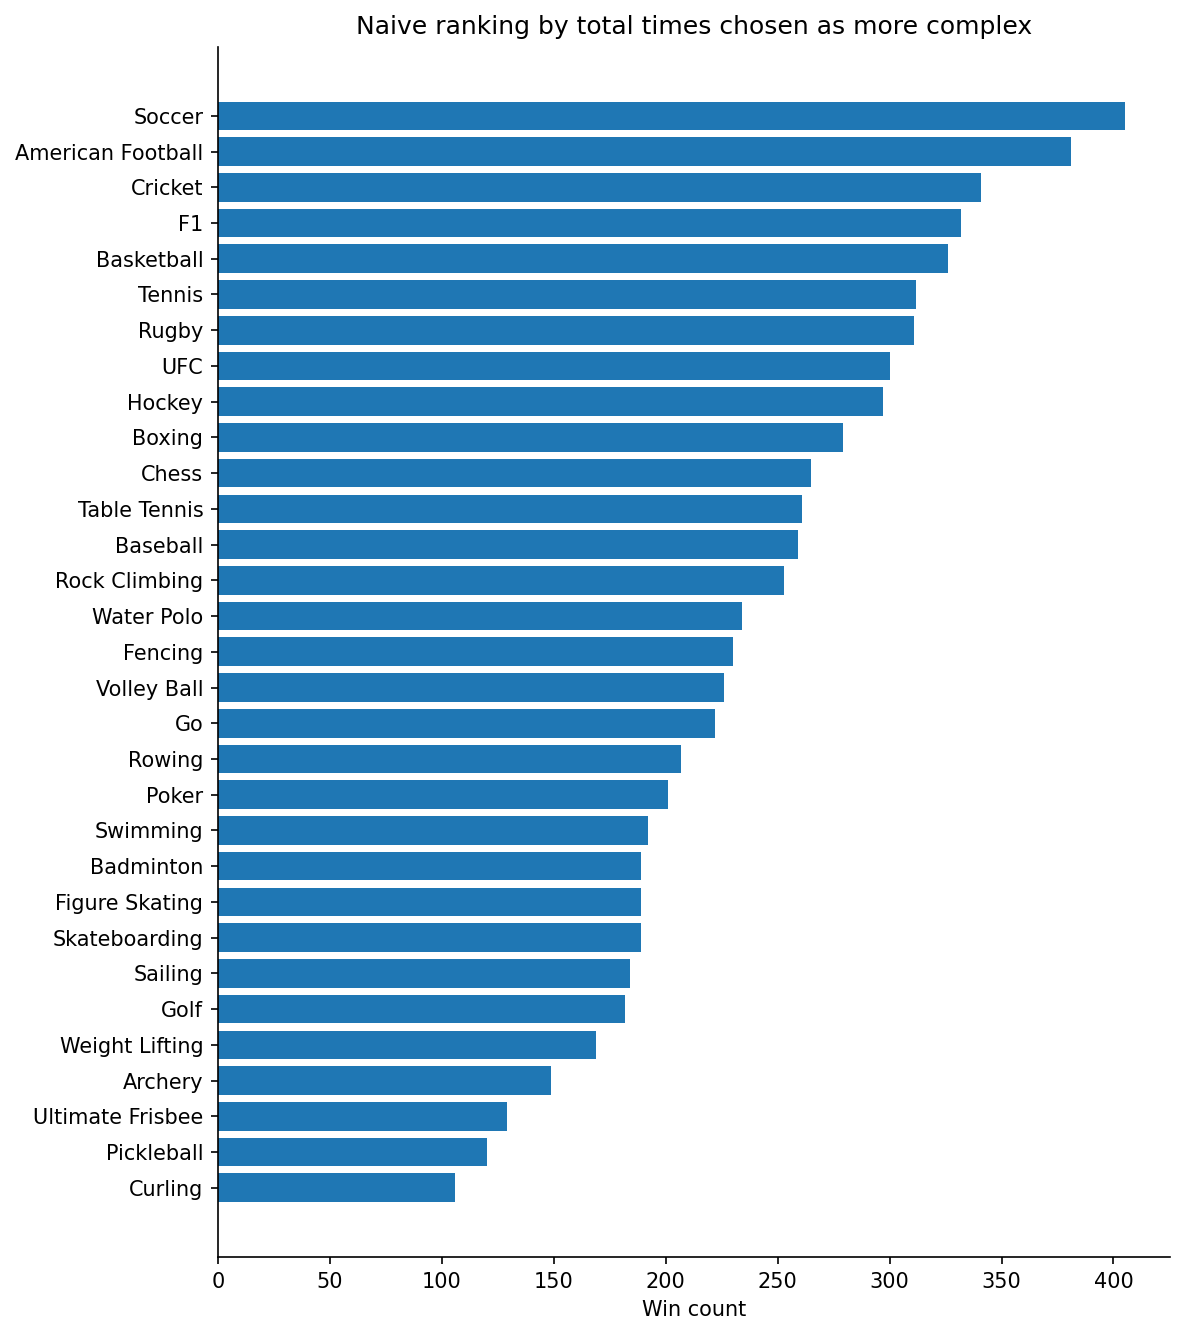

In [9]:
plot_score_bars(
    ranking_df["wins"].to_numpy(),
    ranking_df["sport"].to_numpy(),
    "Naive ranking by total times chosen as more complex",
    "Win count",
)

The naive ranking only remembers **how many** wins each sport got.

It does **not** remember:

- whether the wins came against strong or weak opponents,
- whether the data are globally consistent,
- how much voters disagree,
- how uncertain a close comparison really is.

Those problems are the reason ranking from pairwise comparisons is its own topic.

## 1.2 Transitivity violations

If the ballots reflected one clean linear order, we would expect transitivity:

- if voters prefer $A$ to $B$,
- and prefer $B$ to $C$,
- then they should also prefer $A$ to $C$.

Pairwise data often violate that pattern. The usual symptom is a **cycle**.

In [10]:
# Build the "majority relation" from the pooled count matrix.
# For each pair (i, j), if sport i was chosen as more complex 
# more often than sport j, we say i > j in the majority relation.
# np.sign gives +1, 0, or -1.

majority = np.sign(A - A.T).astype(int)

print(f"Pairs where majority is clear: {(majority != 0).sum() // 2}")
print(f"Tied pairs (equal votes both ways): {(majority == 0).sum() // 2 - len(sports)}")

Pairs where majority is clear: 423
Tied pairs (equal votes both ways): 26


In [11]:
# Count transitivity violations (cycles) in the majority relation.
# For every triple of sports (i, j, k), check if the majority 
# preferences form a cycle: i > j > k > i.
# If all three edges point the same way around the triangle, that's a cycle.

n_triples = 0
majority_cycles = []

for i_idx, j_idx, k_idx in itertools.combinations(range(n), 3):
    tri = (majority[i_idx, j_idx], majority[j_idx, k_idx], majority[k_idx, i_idx])
    if 0 in tri:
        continue  # skip if any pair is tied
    n_triples += 1
    if tri[0] == tri[1] == tri[2]:
        # all three edges point the same direction = cycle
        majority_cycles.append((i_idx, j_idx, k_idx))

print(f"Cyclic triples: {len(majority_cycles)} / {n_triples}")
print(f"Fraction: {len(majority_cycles) / n_triples:.3f}")

Cyclic triples: 41 / 3375
Fraction: 0.012


In [12]:
# Show some example cycles
cycle_examples = []
for i_idx, j_idx, k_idx in majority_cycles[:8]:
    cycle_examples.append({
        "edge 1": f"{sports[i_idx]} > {sports[j_idx]} ({A[i_idx, j_idx]:.0f}-{A[j_idx, i_idx]:.0f})",
        "edge 2": f"{sports[j_idx]} > {sports[k_idx]} ({A[j_idx, k_idx]:.0f}-{A[k_idx, j_idx]:.0f})",
        "edge 3": f"{sports[k_idx]} > {sports[i_idx]} ({A[k_idx, i_idx]:.0f}-{A[i_idx, k_idx]:.0f})",
    })

pd.DataFrame(cycle_examples)

,edge 1,edge 2,edge 3
0,Archery > Badminton (9-7),Badminton > Figure Skating (10-6),Figure Skating > Archery (11-5)
1,Archery > Badminton (9-7),Badminton > Sailing (9-7),Sailing > Archery (9-7)
2,Archery > Badminton (9-7),Badminton > Skateboarding (11-5),Skateboarding > Archery (13-3)
3,Archery > Figure Skating (5-11),Figure Skating > Swimming (6-10),Swimming > Archery (7-9)
4,Archery > Rowing (4-12),Rowing > Swimming (7-9),Swimming > Archery (7-9)
5,Badminton > Figure Skating (10-6),Figure Skating > Volley Ball (9-7),Volley Ball > Badminton (10-6)
6,Badminton > Go (7-9),Go > Weight Lifting (6-10),Weight Lifting > Badminton (7-9)
7,Badminton > Sailing (9-7),Sailing > Swimming (9-7),Swimming > Badminton (10-6)


The pooled majority tournament is **mostly** transitive, but not perfectly so.

That matters. A ranking method is being asked to summarize data that do not reduce to a single clean ordering. Any method that forces a full ranking is smoothing over those local contradictions.

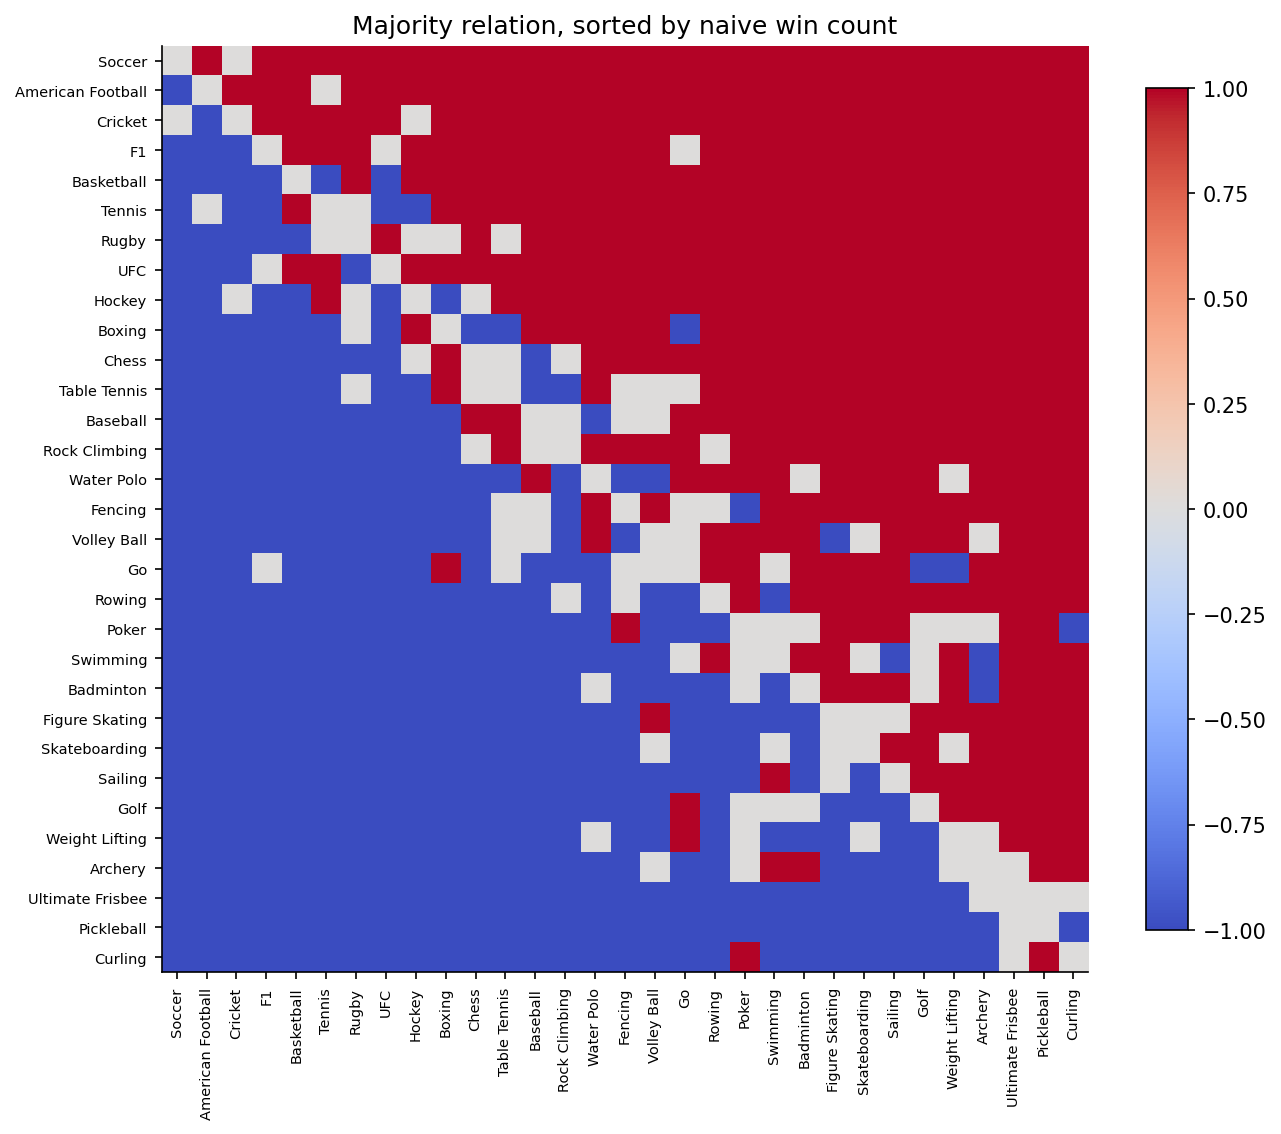

In [13]:
naive_order = ranking_df["sport"].tolist()
naive_idx = [sport_to_idx[sport] for sport in naive_order]
majority_sorted = majority[np.ix_(naive_idx, naive_idx)]

plot_heatmap(
    majority_sorted,
    naive_order,
    "Majority relation, sorted by naive win count",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

## 1.3 Individual voters can be much less consistent than the pool

Pooling 15 voters averages out a lot of noise. A single voter does not get that luxury.

So let us ask the same cycle question voter by voter.

In [14]:
# Same analysis per voter: how many cycles does each individual have?
voter_cycle_rows = []

for voter, rows in ballots.groupby("voter"):
    # Build this voter's relation matrix
    relation = np.zeros((n, n), dtype=int)
    for _, row in rows.iterrows():
        w, l = int(row["winner_idx"]), int(row["loser_idx"])
        relation[w, l] = 1
        relation[l, w] = -1
    
    # Count cycles
    total = 0
    n_cycles = 0
    for i_idx, j_idx, k_idx in itertools.combinations(range(n), 3):
        tri = (relation[i_idx, j_idx], relation[j_idx, k_idx], relation[k_idx, i_idx])
        if 0 in tri:
            continue
        total += 1
        if tri[0] == tri[1] == tri[2]:
            n_cycles += 1
    
    voter_cycle_rows.append({
        "voter": voter,
        "cyclic_triples": n_cycles,
        "total_triples": total,
        "cyclic_fraction": n_cycles / total if total > 0 else 0,
    })

voter_cycle_df = pd.DataFrame(voter_cycle_rows).sort_values("cyclic_fraction", ascending=False)
display(voter_cycle_df)

,voter,cyclic_triples,total_triples,cyclic_fraction
15,voter_15,1130,4495,0.251
8,voter_08,794,4495,0.177
10,voter_10,580,4495,0.129
1,voter_01,527,4495,0.117
12,voter_12,299,4495,0.067
3,voter_03,156,4495,0.035
13,voter_13,145,4495,0.032
7,voter_07,139,4495,0.031
6,voter_06,97,4495,0.022
9,voter_09,85,4495,0.019


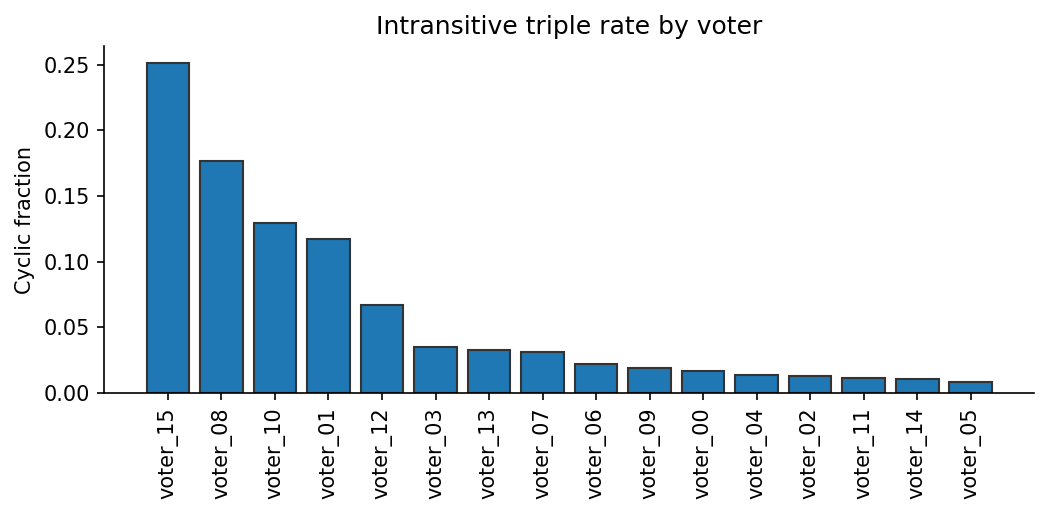

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.bar(voter_cycle_df["voter"], voter_cycle_df["cyclic_fraction"], ec='.2')
ax.set_title("Intransitive triple rate by voter")
ax.set_ylabel("Cyclic fraction")
ax.tick_params(axis="x", rotation=90)

plt.show()

The pool looks cleaner than many of the individuals.

That is normal. Aggregation can reduce noise and reveal broad structure, but it can also hide just how different people's internal rankings really are.

## 1.4 Who beats whom matters

Here is the next problem with raw win counts.

Suppose two teams both have 3 wins. One got those wins against very strong opponents; the other got them against weak opponents. A plain count says they are tied. Most analysts would not.

In [16]:
toy_resume = pd.DataFrame({
    "team": ["Alpha", "Beta"],
    "wins": [3, 3],
    "who_they_beat": ["A, B, C", "D, E, F"],
    "opponent_strength_sum": [24, 3],
})

display(toy_resume)

,team,wins,who_they_beat,opponent_strength_sum
0,Alpha,3,"A, B, C",24
1,Beta,3,"D, E, F",3


That toy example is extreme on purpose.

In our survey, the schedule is almost perfectly balanced: every sport is compared against almost every other sport the same number of times. So strength-of-schedule issues should be **smaller here than in a real league**.

Smaller is not the same as zero.

In [17]:
opponent_quality = (A * win_counts[None, :]).sum(axis=1) / np.maximum(win_counts, 1)

close_rows = []
for i, j in itertools.combinations(range(n), 2):
    if abs(win_counts[i] - win_counts[j]) <= 4:
        close_rows.append({
            "sport_a": sports[i],
            "wins_a": win_counts[i],
            "avg_beaten_opp_wins_a": opponent_quality[i],
            "sport_b": sports[j],
            "wins_b": win_counts[j],
            "avg_beaten_opp_wins_b": opponent_quality[j],
            "gap_in_avg_beaten_opp_wins": abs(opponent_quality[i] - opponent_quality[j]),
        })

close_df = pd.DataFrame(close_rows).sort_values("gap_in_avg_beaten_opp_wins", ascending=False)
display(close_df.head(6))

,sport_a,wins_a,avg_beaten_opp_wins_a,sport_b,wins_b,avg_beaten_opp_wins_b,gap_in_avg_beaten_opp_wins
9,Go,222,221.140,Volley Ball,226,210.239,10.901
2,Badminton,189,205.021,Swimming,192,213.120,8.099
0,Badminton,189,205.021,Figure Skating,189,211.635,6.614
12,Rugby,311,214.971,Tennis,312,220.952,5.981
1,Badminton,189,205.021,Skateboarding,189,209.984,4.963
13,Skateboarding,189,209.984,Swimming,192,213.120,3.136


That last table is only a rough diagnostic, not a formal ranking method.

The point is simpler: even in a balanced design, *which* wins you collect can matter. In this dataset the effect is mild, which helps explain why several methods later on end up very close to each other.

## 1.5 Voter disagreement

A pairwise comparison is easy to state, but not always easy to agree on.

For each unordered pair of sports, we can ask: what fraction of voters chose the same winner?

In [18]:
agreement = np.full((n, n), np.nan)
pair_rows = []

for i, j in itertools.combinations(range(n), 2):
    total = N[i, j]
    agree = max(A[i, j], A[j, i]) / total
    agreement[i, j] = agree
    agreement[j, i] = agree
    pair_rows.append({
        "sport_a": sports[i],
        "sport_b": sports[j],
        "wins_a": A[i, j],
        "wins_b": A[j, i],
        "agreement": agree,
    })

np.fill_diagonal(agreement, 1.0)
pair_agreement_df = pd.DataFrame(pair_rows).sort_values("agreement")

In [19]:

print(f"Unanimous pairs: {(pair_agreement_df['agreement'] == 1.0).sum()}")
pair_agreement_df["agreement"].describe()


Unanimous pairs: 6


count   465.000
mean      0.699
std       0.125
min       0.500
25%       0.625
50%       0.688
75%       0.812
max       1.000
Name: agreement, dtype: float64

In [20]:
display(pair_agreement_df.head(10))

,sport_a,sport_b,wins_a,wins_b,agreement
464,Water Polo,Weight Lifting,8,8,0.500
195,Cricket,Hockey,8,8,0.500
426,Skateboarding,Volley Ball,8,8,0.500
182,Chess,Table Tennis,8,8,0.500
428,Skateboarding,Weight Lifting,8,8,0.500
175,Chess,Rock Climbing,8,8,0.500
153,Boxing,Rugby,8,8,0.500
373,Poker,Weight Lifting,8,8,0.500
203,Cricket,Soccer,8,8,0.500
374,Rock Climbing,Rowing,8,8,0.500


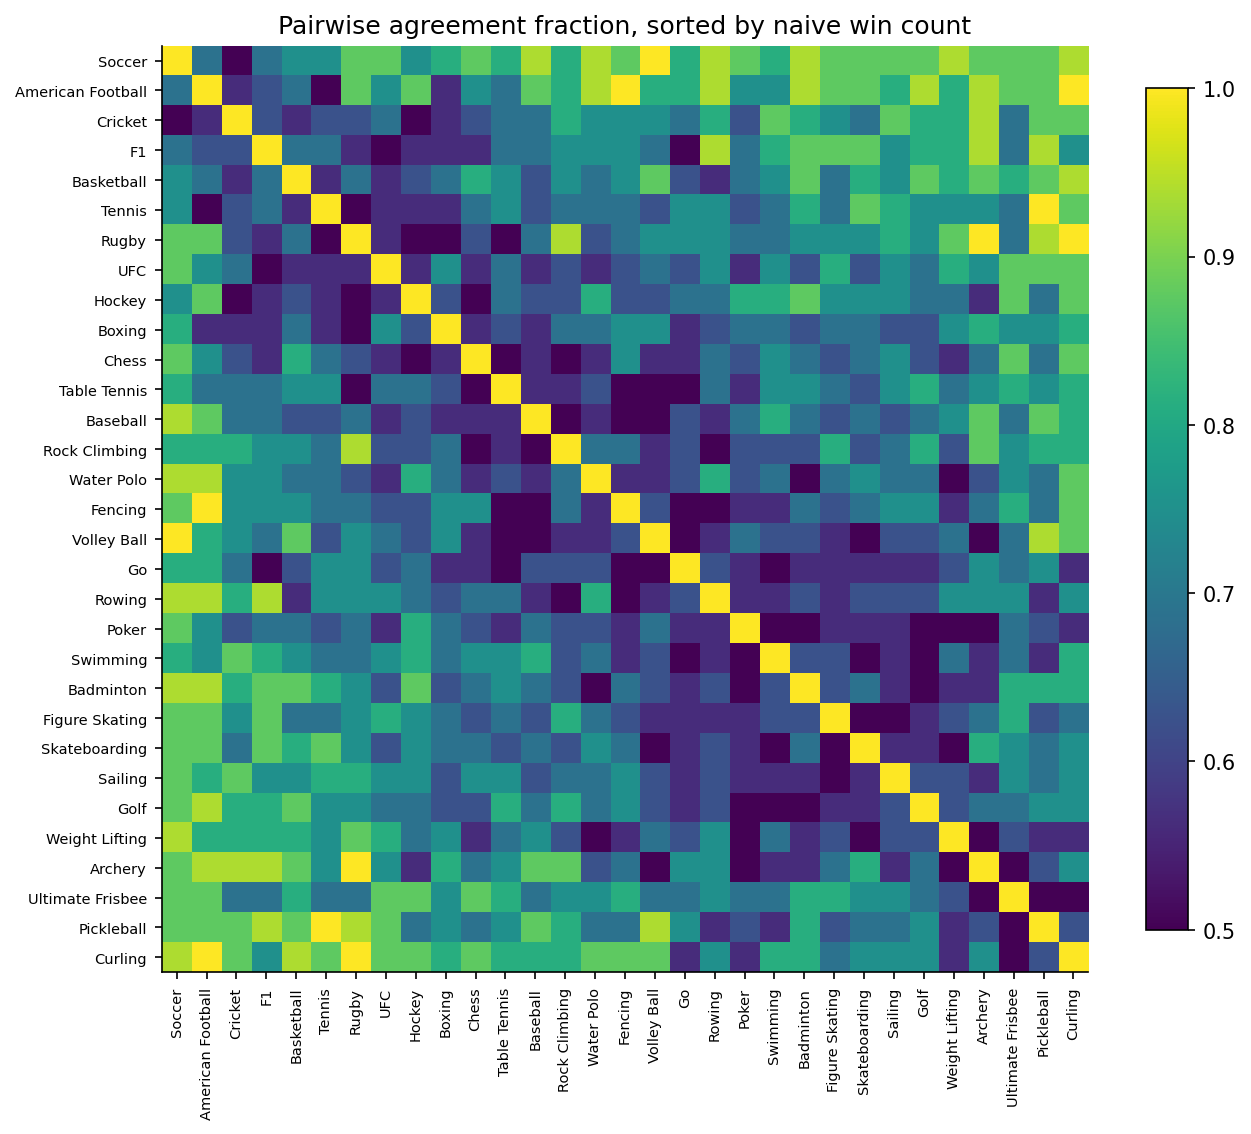

In [21]:
agreement_sorted = agreement[np.ix_(naive_idx, naive_idx)]

plot_heatmap(
    agreement_sorted,
    naive_order,
    "Pairwise agreement fraction, sorted by naive win count",
    vmin=0.5,
    vmax=1.0,
    cmap="viridis",
)

The bright diagonal and dark off-diagonal blocks show that agreement is highest for pairs that are far apart in the naive ranking (e.g., Chess vs. Curling — everyone agrees Chess is more complex). The muddiest cells are between sports that are close in overall win count: voters genuinely disagree about whether, say, Soccer is more complex than Hockey.

The overall pattern: the ranking is sharpest at the extremes and fuzziest in the middle. This is what you'd expect if there's a rough consensus on which sports are most and least complex, but the exact ordering of the "middle tier" is noisy and subjective.

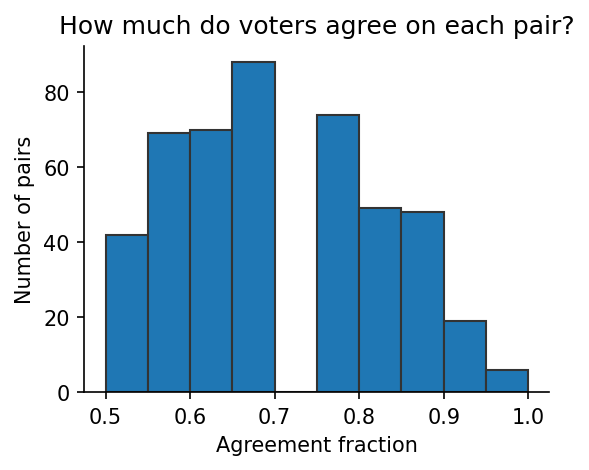

In [22]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.hist(pair_agreement_df["agreement"], bins=np.linspace(0.5, 1.0, 11), ec='.2')
ax.set_title("How much do voters agree on each pair?")
ax.set_xlabel("Agreement fraction")
ax.set_ylabel("Number of pairs")

plt.show()

There are plenty of close calls. Several pairs are split 8-8.

So even before we fit a model, we already know the ranking problem has three complications:

1. the pairwise relation has local cycles,
2. wins are not all equally informative,
3. different voters do not see the sports the same way.

A second way to see disagreement is to compare the *whole rankings* different voters imply.

In [23]:
voter_win = pd.DataFrame(index=sports)
for voter, rows in ballots.groupby("voter"):
    A_v = count_matrix_from_rows(rows, n)
    voter_win[voter] = A_v.sum(axis=1)

voter_rank = voter_win.rank(axis=0, ascending=False, method="average")
voter_spearman = pd.DataFrame(index=voters, columns=voters, dtype=float)

for v1 in voters:
    for v2 in voters:
        voter_spearman.loc[v1, v2] = spearmanr(voter_rank[v1], voter_rank[v2]).statistic

mean_off_diag = np.nanmean(voter_spearman.to_numpy()[~np.eye(len(voters), dtype=bool)])
print(f"Mean off-diagonal Spearman correlation: {mean_off_diag:0.3f}")
display(voter_spearman.round(3))

Mean off-diagonal Spearman correlation: 0.285


,voter_00,voter_01,voter_02,voter_03,voter_04,voter_05,voter_06,voter_07,voter_08,voter_09,voter_10,voter_11,voter_12,voter_13,voter_14,voter_15
voter_00,1.000,0.090,0.757,0.015,0.479,0.277,0.309,0.184,0.096,0.533,0.448,0.262,0.341,0.457,0.713,0.094
voter_01,0.090,1.000,-0.099,-0.117,-0.017,0.236,0.307,0.254,0.125,0.071,0.312,0.288,0.302,0.184,-0.046,0.205
voter_02,0.757,-0.099,1.000,-0.135,0.461,0.241,0.071,0.162,-0.052,0.274,0.194,0.080,0.109,0.144,0.359,0.053
voter_03,0.015,-0.117,-0.135,1.000,0.300,-0.033,-0.006,-0.346,-0.114,-0.011,-0.063,0.144,-0.039,0.164,0.145,0.097
voter_04,0.479,-0.017,0.461,0.300,1.000,0.571,0.302,0.335,0.121,0.405,0.378,0.598,0.366,0.412,0.222,-0.068
voter_05,0.277,0.236,0.241,-0.033,0.571,1.000,0.669,0.764,0.243,0.494,0.693,0.529,0.451,0.458,-0.037,-0.094
voter_06,0.309,0.307,0.071,-0.006,0.302,0.669,1.000,0.679,0.581,0.579,0.728,0.703,0.706,0.561,0.077,-0.222
voter_07,0.184,0.254,0.162,-0.346,0.335,0.764,0.679,1.000,0.376,0.387,0.678,0.512,0.473,0.324,-0.002,-0.230
voter_08,0.096,0.125,-0.052,-0.114,0.121,0.243,0.581,0.376,1.000,0.561,0.429,0.542,0.480,0.444,-0.072,-0.023
voter_09,0.533,0.071,0.274,-0.011,0.405,0.494,0.579,0.387,0.561,1.000,0.766,0.511,0.577,0.849,0.318,0.182


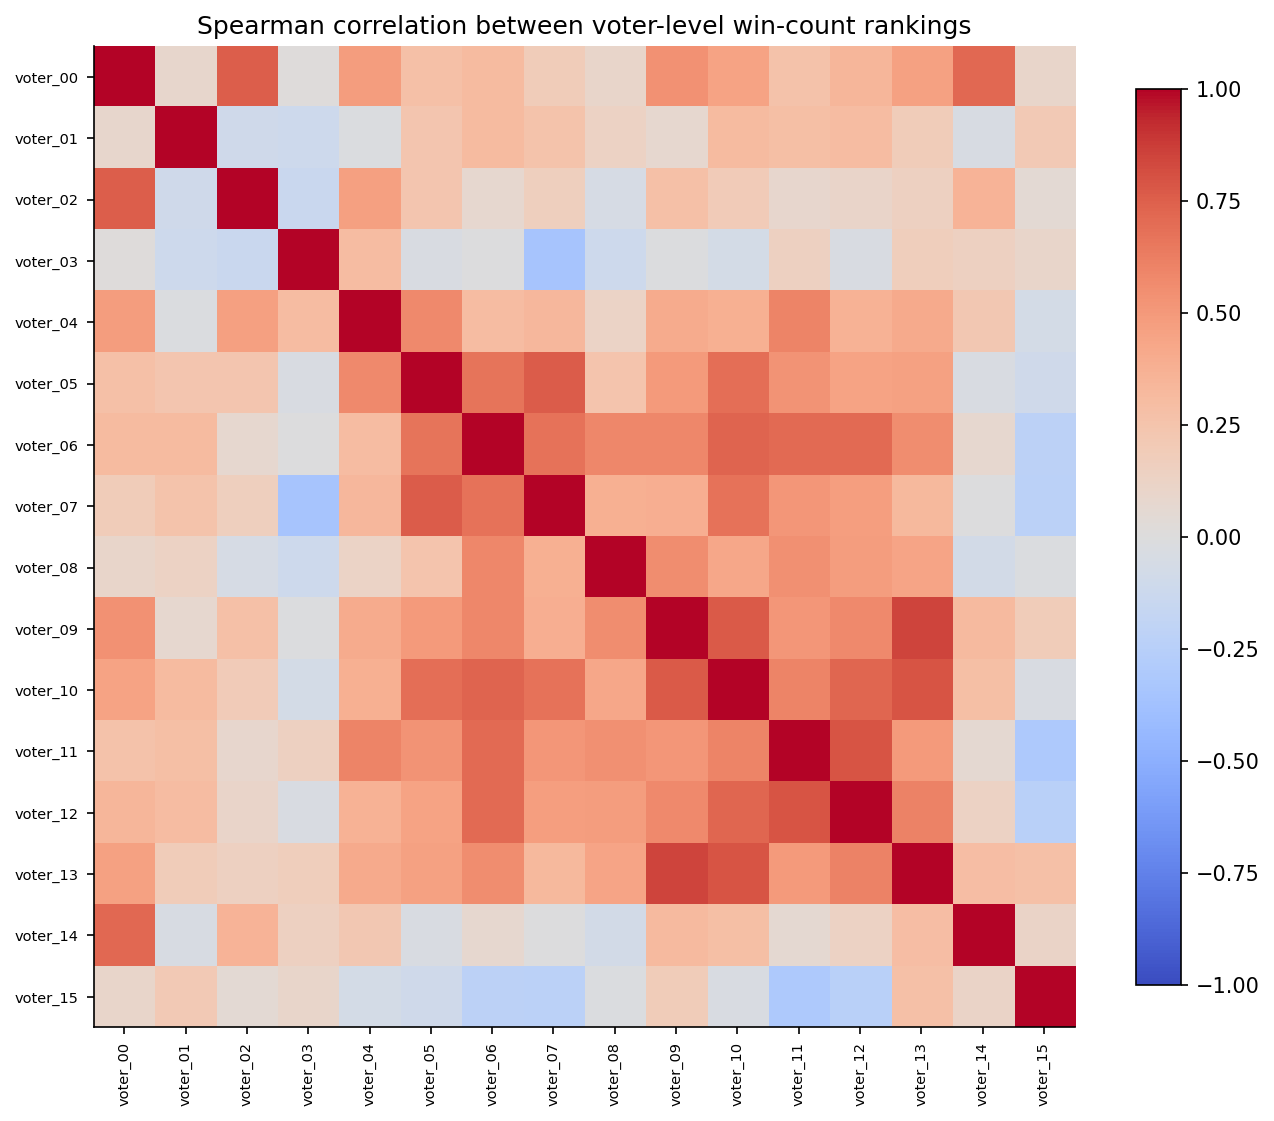

In [24]:
plot_heatmap(
    voter_spearman.to_numpy(),
    voter_spearman.index.tolist(),
    "Spearman correlation between voter-level win-count rankings",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

## Part I takeaway

A win count is a useful baseline, but maybe not the whole thing! That is enough motivation to move to models that treat pairwise comparisons as data, not just as tallies.

## Your turn!

Pick one of the 8-8 pairs in the table above.

- Does that pair surprise you?
- If you had to explain the split, would you say the voters disagree about **complexity**, about **familiarity**, or about **what counts as complexity**?

# Part II: Bradley-Terry, the foundational model

## 2.1 One latent score per sport

Bradley-Terry says each sport $i$ has a latent strength $\beta_i$.

In this notebook, "strength" means **perceived complexity**. If $\beta_i$ is much larger than $\beta_j$, the model says sport $i$ should usually beat sport $j$ in a head-to-head comparison.

![](images/bt.png)

### Who were Bradley and Terry?

The model is named after Ralph Allan Bradley and Milton Terry, who published it in 1952 in *Biometrika*. But the same idea was discovered independently — and earlier — by the mathematician Ernst Zermelo in 1929, in the context of chess tournaments. Zermelo proved that the maximum-likelihood solution exists and is unique (under mild conditions), and proposed an iterative algorithm to find it. The model is sometimes called the Bradley-Terry-Zermelo model.

The core idea — that you can recover a latent linear scale from noisy pairwise comparisons — goes back even further, to L. L. Thurstone’s 1927 "Law of Comparative Judgment" in psychology. Thurstone used a normal distribution where Bradley-Terry uses a logistic, but the models are nearly indistinguishable in practice.

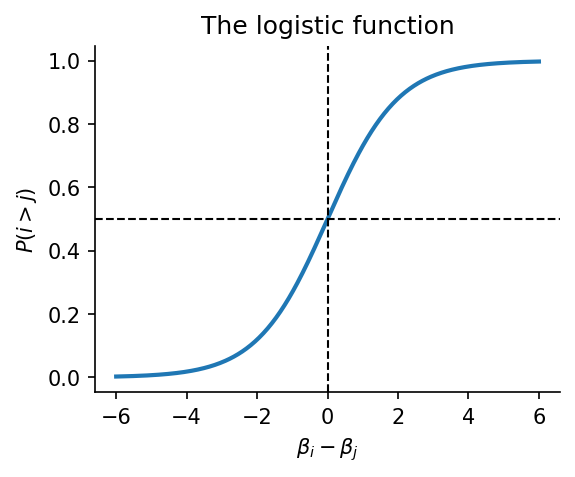

In [25]:
x = np.linspace(-6, 6, 400)

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(x, sigmoid(x), lw=2)
ax.axvline(0, linestyle="--", color="black", linewidth=1)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_title("The logistic function")
ax.set_xlabel(r"$\beta_i - \beta_j$")
ax.set_ylabel(r"$P(i > j)$")

plt.show()

The Bradley-Terry probability model is

$$
P(i > j) = \sigma(\beta_i - \beta_j) = \frac{1}{1 + e^{-(\beta_i - \beta_j)}}.
$$

This choice does exactly what we want:

- it maps any real-valued score difference to a number between 0 and 1,
- equal scores give probability $0.5$,
- swapping $i$ and $j$ flips the probability in the right way.

In [26]:
gap_df = pd.DataFrame({"beta_gap": [-2, -1, 0, 1, 2]})
gap_df["win_probability"] = sigmoid(gap_df["beta_gap"])
display(gap_df)

,beta_gap,win_probability
0,-2,0.119
1,-1,0.269
2,0,0.500
3,1,0.731
4,2,0.881


## 2.2 What does "fit by maximum likelihood" mean?

We want the $\beta_i$ values that make the observed ballots look as plausible as possible under the model. Parameter settings that assign high probability to the comparisons that actually happened get rewarded. Parameter settings that keep predicting coin flips when the data are lopsided get penalized.

The Bradley-Terry equation gives us the probability that $i$ beats $j$:

$$
P(i \text{ wins}) = \sigma(\beta_i - \beta_j)
$$

which means the probability that $j$ beats $i$ is:

$$
P(j \text{ wins}) = 1 - \sigma(\beta_i - \beta_j)
$$

So for any comparison between $i$ and $j$, there are two cases. We want a single expression that handles both. The trick is to use $y$ as an exponent, where $y = 1$ if $i$ wins and $y = 0$ if $j$ wins:

$$
P(\text{outcome}) = \sigma(\beta_i - \beta_j)^{y} \cdot \left(1 - \sigma(\beta_i - \beta_j)\right)^{1-y}
$$

Check the two cases:

- If $y = 1$ (sport $i$ wins): the first factor is $\sigma(\beta_i - \beta_j)^1$ and the second is $(1 - \sigma)^0 = 1$. So we get $\sigma(\beta_i - \beta_j)$.
- If $y = 0$ (sport $j$ wins): the first factor is $\sigma(\beta_i - \beta_j)^0 = 1$ and the second is $(1 - \sigma)^1$. So we get $1 - \sigma(\beta_i - \beta_j)$.

Now we apply this to the full dataset. For comparison $m$, let $i_m$ be `Sport_1`, let $j_m$ be `Sport_2`, and let

$$
y_m =
\begin{cases}
1 & \text{if Sport\_1 wins} \\
0 & \text{if Sport\_2 wins.}
\end{cases}
$$

Using the same exponent trick, the probability of the observed outcome for comparison $m$ is:

$$
P(\text{outcome } m) = \sigma(\beta_{i_m} - \beta_{j_m})^{y_m} \cdot \left(1 - \sigma(\beta_{i_m} - \beta_{j_m})\right)^{1 - y_m}.
$$

Assuming the comparisons are independent, the probability of the entire dataset is the product over all $M$ comparisons. Taking the log (because products of hundreds of small numbers are numerically terrible, and sums are not):

$$
\ell(\beta)
=
\sum_{m=1}^M
\left[
y_m \log \sigma(\beta_{i_m} - \beta_{j_m})
+
(1-y_m)\log \left(1-\sigma(\beta_{i_m} - \beta_{j_m})\right)
\right].
$$

Each term in the sum is the log-probability of one observed comparison under the current $\beta$ values. Terms where the model confidently predicts the right answer contribute values close to 0 (since $\log(1) = 0$). Terms where the model is surprised — it predicted one sport would win but the other did — contribute large negative values. Maximizing $\ell(\beta)$ pushes the model toward parameter values that are least surprised by the data.

We maximize $\ell(\beta)$, or equivalently minimize $-\ell(\beta)$ (the negative log-likelihood), since optimization libraries are usually set up for minimization.


One identifiability detail: if we add the same constant to every $\beta_i$, every difference $\beta_i - \beta_j$ stays the same. So the model cannot tell absolute level, only **relative differences**. The usual fix is to pin one reference sport to zero and center the fitted scores afterward.

## 2.3 Bradley-Terry is logistic regression with a special design matrix

In [27]:
# Build the design matrix for Bradley-Terry as logistic regression.
#
# The idea: each comparison (i vs j) becomes one row in a matrix X.
# That row has +1 in column i and -1 in column j (all other entries 0).
# When we compute X @ beta, each row gives beta_i - beta_j,
# which is exactly the score difference Bradley-Terry needs.
#
# We drop one sport as a "reference" (its beta is fixed at 0)
# to make the parameters identifiable --- otherwise we could
# shift all betas by the same constant and get the same predictions.

def build_bt_design_matrix(i_arr, j_arr, n, reference=None):
    # By default, use the last sport as the reference (beta = 0)
    if reference is None:
        reference = n - 1

    # 'keep' is a boolean mask: True for all sports except the reference
    keep = np.arange(n) != reference

    # col_map translates sport index -> column index in the design matrix
    # The reference sport gets -1 (no column), everyone else gets 0..(n-2)
    col_map = -np.ones(n, dtype=int)
    col_map[keep] = np.arange(n - 1)

    # X has one row per comparison, one column per non-reference sport
    X = np.zeros((len(i_arr), n - 1))
    rows = np.arange(len(i_arr))

    # For each comparison, put +1 in Sport_1's column and -1 in Sport_2's column
    # (skip if the sport is the reference, since its beta is fixed at 0)
    mask_i = i_arr != reference
    mask_j = j_arr != reference
    X[rows[mask_i], col_map[i_arr[mask_i]]] = 1.0
    X[rows[mask_j], col_map[j_arr[mask_j]]] = -1.0


    return X, keep, reference

In [28]:
toy_ballots = pd.DataFrame({
    "Sport_1": ["A", "A", "B", "A", "C"],
    "Sport_2": ["B", "C", "C", "D", "D"],
    "choice": [1, 1, 2, 2, 1],
})

toy_sports = sorted(set(toy_ballots["Sport_1"]).union(toy_ballots["Sport_2"]))
toy_to_idx = {sport: idx for idx, sport in enumerate(toy_sports)}

toy_i = toy_ballots["Sport_1"].map(toy_to_idx).to_numpy()
toy_j = toy_ballots["Sport_2"].map(toy_to_idx).to_numpy()
toy_X, toy_keep, toy_ref = build_bt_design_matrix(toy_i, toy_j, len(toy_sports))

toy_design = pd.DataFrame(
    toy_X,
    columns=[sport for sport in toy_sports if sport != toy_sports[toy_ref]],
)
toy_design["y"] = (toy_ballots["choice"] == 1).astype(int)

display(pd.concat([toy_ballots, toy_design], axis=1))

,Sport_1,Sport_2,choice,A,B,C,y
0,A,B,1,1.000,-1.000,0.000,1
1,A,C,1,1.000,0.000,-1.000,1
2,B,C,2,0.000,1.000,-1.000,0
3,A,D,2,1.000,0.000,0.000,0
4,C,D,1,0.000,0.000,1.000,1


Each row has a `+1` for `Sport_1` and a `-1` for `Sport_2`.

So when we compute $X\theta$, each row becomes exactly one score difference: $\beta_i - \beta_j$. That is why Bradley-Terry drops into logistic regression so neatly.

## 2.4 Fitting Bradley-Terry from scratch

We need to find the $\beta$ values that maximize the log-likelihood. In practice, we minimize the *negative* log-likelihood using `scipy.optimize.minimize`.

What does `minimize` do? It takes a function and a starting point, then uses an iterative algorithm (by default L-BFGS-B, a quasi-Newton method) to find the input that makes the function as small as possible. We don’t need to understand the optimizer’s internals — we just need to hand it the right objective function and a reasonable starting point (all zeros works fine here).

In [29]:
def fit_bradley_terry(i_arr, j_arr, choice_arr, n, reference=None, maxiter=500):
    """Fit Bradley-Terry model by minimizing negative log-likelihood."""
    # Build the design matrix (one row per comparison, +1/-1 encoding)
    X, keep, reference = build_bt_design_matrix(i_arr, j_arr, n, reference)
    
    # y = 1 if Sport_1 won, 0 if Sport_2 won
    y = (choice_arr == 1).astype(float)

    def objective(theta):
        # Negative log-likelihood of the logistic model
        z = X @ theta                     # score differences for each comparison
        return np.sum(softplus(z) - y * z)  # -sum[y*log(p) + (1-y)*log(1-p)]

    def gradient(theta):
        # Gradient of the negative log-likelihood
        z = X @ theta
        return X.T @ (sigmoid(z) - y)  # predicted - observed

    # Find the beta values that minimize the negative log-likelihood
    result = minimize(
        objective,
        np.zeros(n - 1),      # start from all zeros
        jac=gradient,          # provide analytical gradient (faster)
        method="L-BFGS-B",     # quasi-Newton optimizer
        options={"maxiter": maxiter},
    )

    # Map back to full beta vector (reference sport gets beta = 0)
    beta = np.zeros(n)
    beta[keep] = result.x
    beta -= beta.mean()  # center so mean beta = 0
    return beta, result

In [30]:
toy_beta, toy_result = fit_bradley_terry(
    toy_i,
    toy_j,
    toy_ballots["choice"].to_numpy(),
    len(toy_sports),
)

print("Optimizer success:", toy_result.success)

display(
    pd.DataFrame({"sport": toy_sports, "beta": toy_beta})
    .sort_values("beta", ascending=False)
)

Optimizer success: True


,sport,beta
3,D,4.889
0,A,4.889
2,C,4.889
1,B,-14.668


That toy fit is only there to make the mechanics visible.

Now we use the real survey data.

In [31]:
beta_bt, bt_result = fit_bradley_terry(
    ballots["i"].to_numpy(),
    ballots["j"].to_numpy(),
    ballots["choice"].to_numpy(),
    n,
)

bt_df = pd.DataFrame({"sport": sports, "beta": beta_bt})
bt_df = bt_df.sort_values(["beta", "sport"], ascending=[False, True]).reset_index(drop=True)

print("Optimizer success:", bt_result.success)
display(bt_df.head(12))

Optimizer success: True


,sport,beta
0,Soccer,1.773
1,American Football,1.430
2,Cricket,0.959
3,F1,0.863
4,Basketball,0.801
5,Tennis,0.661
6,Rugby,0.651
7,UFC,0.544
8,Hockey,0.515
9,Boxing,0.346


## 2.5 A quick verification: compare to `scikit-learn`

If `scikit-learn` is available, we can fit the same design matrix with ordinary logistic regression and check that the coefficients line up.

In [32]:
# Verify our from-scratch fit matches sklearn's LogisticRegression
from sklearn.linear_model import LogisticRegression

X_full, keep, reference = build_bt_design_matrix(
    ballots["i"].to_numpy(), ballots["j"].to_numpy(), n
)
y_full = (ballots["choice"].to_numpy() == 1).astype(float)

# Fit logistic regression with no intercept, weak regularization
clf = LogisticRegression(
    fit_intercept=False,
    penalty="l2",
    C=1e4,             # very weak regularization (large C = less penalty)
    solver="lbfgs",
    max_iter=5000,
)
clf.fit(X_full, y_full)

# Reconstruct full beta vector and center
beta_sklearn = np.zeros(n)
beta_sklearn[keep] = clf.coef_.ravel()
beta_sklearn -= beta_sklearn.mean()

print(f"Max absolute difference (scratch vs sklearn): {np.max(np.abs(beta_sklearn - beta_bt)):.6f}")
print("Should be very small (< 0.01).")

Max absolute difference (scratch vs sklearn): 0.001330
Should be very small (< 0.01).


/Users/brennan/.conda/envs/cnet5442/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 2.6 The Bradley-Terry ranking on the sports data

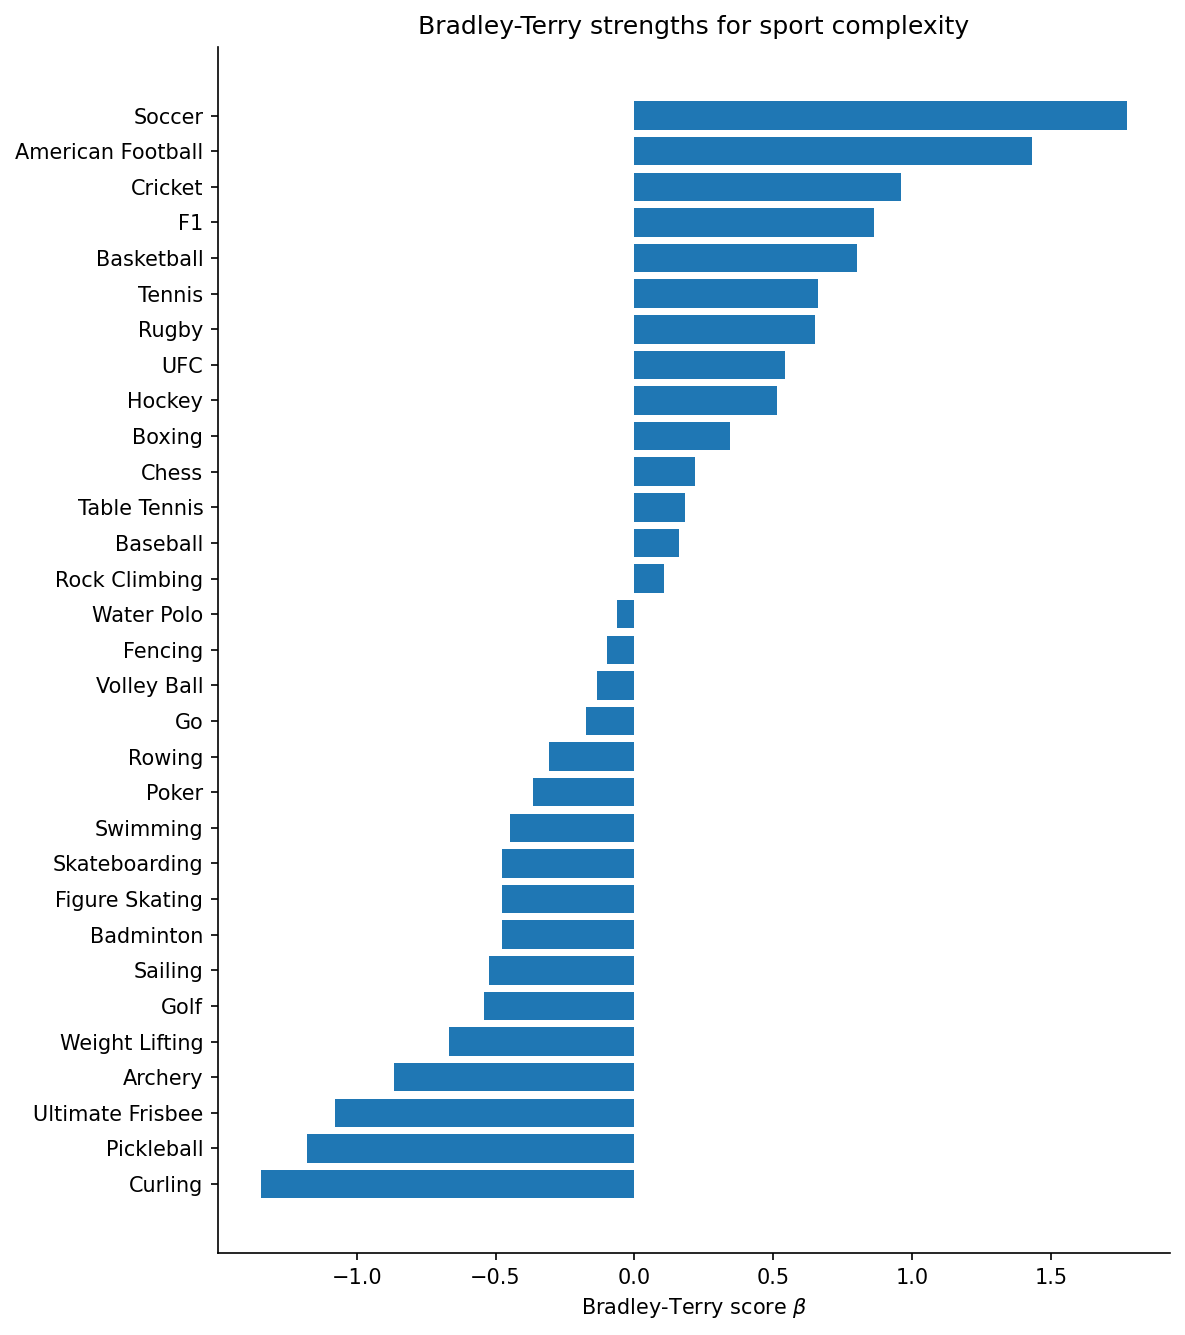

In [33]:
plot_score_bars(
    bt_df["beta"].to_numpy(),
    bt_df["sport"].to_numpy(),
    "Bradley-Terry strengths for sport complexity",
    r"Bradley-Terry score $\beta$",
)

Now compare Bradley-Terry to the naive win-count ranking.

Given everything we said in Part I, you might expect a lot of disagreement. In this particular dataset, you should not.

In [34]:
rank_compare = pd.DataFrame({
    "sport": sports,
    "wins": win_counts,
    "bt": np.round(beta_bt, 10),
})

rank_compare["win_rank"] = rank_compare["wins"].rank(ascending=False, method="min").astype(int)
rank_compare["bt_rank"] = rank_compare["bt"].rank(ascending=False, method="min").astype(int)
rank_compare["abs_rank_diff"] = (rank_compare["win_rank"] - rank_compare["bt_rank"]).abs()

display(rank_compare.sort_values(["abs_rank_diff", "win_rank"], ascending=[False, True]).head(12))
print("Largest rank difference:", rank_compare["abs_rank_diff"].max())

,sport,wins,bt,win_rank,bt_rank,abs_rank_diff
22,Soccer,405,1.773,1,1,0
0,American Football,381,1.430,2,2,0
7,Cricket,341,0.959,3,3,0
9,F1,332,0.863,4,4,0
4,Basketball,326,0.801,5,5,0
25,Tennis,312,0.661,6,6,0
19,Rugby,311,0.651,7,7,0
26,UFC,300,0.544,8,8,0
14,Hockey,297,0.515,9,9,0
5,Boxing,279,0.346,10,10,0


Largest rank difference: 0


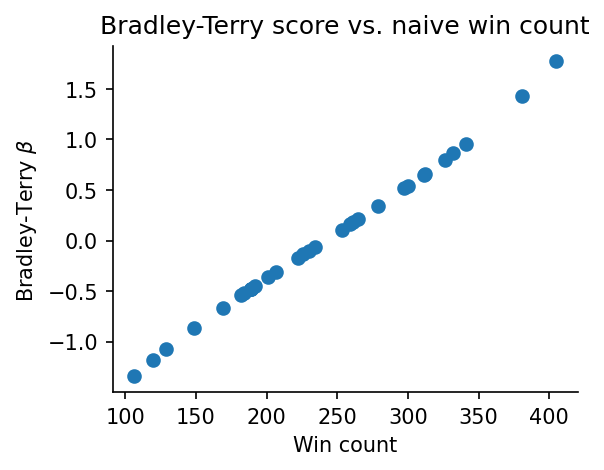

In [35]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.scatter(win_counts, beta_bt)
ax.set_title("Bradley-Terry score vs. naive win count")
ax.set_xlabel("Win count")
ax.set_ylabel(r"Bradley-Terry $\beta$")

plt.show()

Bradley-Terry and raw win count are almost the same here (lol...)

- the comparison design is nearly perfectly balanced,
- every sport faces almost the same schedule,
- the pooled majority relation has relatively few cycles.

Appendix A comes back to this point formally. In a balanced round robin, score-and-sort baselines can track much more sophisticated models surprisingly well.

## 2.7 Diagnostics: do the fitted probabilities mean what they say?

In [36]:
pair_prob_rows = []

for i, j in itertools.combinations(range(n), 2):
    total = N[i, j]
    p_i = sigmoid(beta_bt[i] - beta_bt[j])
    obs_i = A[i, j] / total

    if p_i >= 0.5:
        pair_prob_rows.append({
            "favorite": sports[i],
            "underdog": sports[j],
            "predicted": p_i,
            "observed": obs_i,
            "comparisons": total,
        })
    else:
        pair_prob_rows.append({
            "favorite": sports[j],
            "underdog": sports[i],
            "predicted": 1 - p_i,
            "observed": 1 - obs_i,
            "comparisons": total,
        })

pair_prob_df = pd.DataFrame(pair_prob_rows)
pair_prob_df["abs_error"] = (pair_prob_df["predicted"] - pair_prob_df["observed"]).abs()

bins = np.linspace(0.5, 1.0, 7)
pair_prob_df["bin"] = pd.cut(pair_prob_df["predicted"], bins=bins, include_lowest=True)

calibration_df = (
    pair_prob_df
    .groupby("bin", observed=False)
    .agg(
        mean_predicted=("predicted", "mean"),
        mean_observed=("observed", "mean"),
        pairs=("favorite", "size"),
    )
    .reset_index()
)

display(calibration_df)

,bin,mean_predicted,mean_observed,pairs
0,"(0.499, 0.583]",0.542,0.556,109
1,"(0.583, 0.667]",0.625,0.649,114
2,"(0.667, 0.75]",0.707,0.706,103
3,"(0.75, 0.833]",0.788,0.791,82
4,"(0.833, 0.917]",0.873,0.862,49
5,"(0.917, 1.0]",0.938,0.906,8


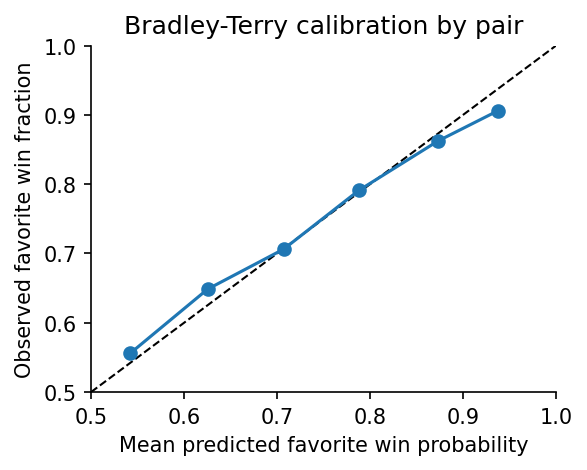

In [37]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.plot([0.5, 1.0], [0.5, 1.0], linestyle="--", color="black", linewidth=1)
ax.plot(calibration_df["mean_predicted"], calibration_df["mean_observed"], marker="o")

ax.set_title("Bradley-Terry calibration by pair")
ax.set_xlabel("Mean predicted favorite win probability")
ax.set_ylabel("Observed favorite win fraction")
ax.set_xlim(0.5, 1.0)
ax.set_ylim(0.5, 1.0)

plt.show()

In [38]:
display(
    pair_prob_df
    .sort_values("abs_error", ascending=False)
    .head(10)
)

,favorite,underdog,predicted,observed,comparisons,abs_error,bin
375,Rugby,Rock Climbing,0.632,0.938,16,0.305,"(0.583, 0.667]"
219,Poker,Curling,0.727,0.438,16,0.290,"(0.667, 0.75]"
397,Water Polo,Rowing,0.561,0.812,16,0.252,"(0.499, 0.583]"
311,Go,Weight Lifting,0.621,0.375,16,0.246,"(0.583, 0.667]"
236,F1,Go,0.738,0.500,16,0.238,"(0.667, 0.75]"
42,Hockey,Archery,0.799,0.562,16,0.237,"(0.75, 0.833]"
49,Skateboarding,Archery,0.596,0.812,16,0.216,"(0.583, 0.667]"
215,Go,Curling,0.763,0.562,16,0.201,"(0.75, 0.833]"
160,UFC,Boxing,0.549,0.750,16,0.201,"(0.499, 0.583]"
357,Volley Ball,Pickleball,0.739,0.938,16,0.198,"(0.667, 0.75]"


The calibration curve is pretty good.

That does **not** mean the model is perfect. It means the model's probabilities are on the right scale overall. The worst-fit pairs are still useful because they show us where one-dimensional strength scores are too simple.

## Your turn!

Find one pair that Bradley-Terry misses badly.

- Does the miss come from a real local cycle?
- Is the pair just close enough that 15 votes is a small sample?
- Or does this pair suggest that "complexity" might have more than one dimension?

# Part III: Elo ratings

## 3.1 Elo updates ratings one comparison at a time

Bradley-Terry looks at all the data at once and solves an optimization problem.

Elo does something lighter. It processes one comparison, updates the two affected ratings, and moves on. That is why Elo is so useful in live systems like chess servers, online games, and pairwise model evaluation leaderboards.

![](images/elo.png)

### Who was Elo?

Arpad Elo (1903-1992) was a Hungarian-American physics professor and chess master who developed his rating system for the United States Chess Federation in the 1960s. FIDE (the international chess federation) adopted it in 1970. Elo’s key insight was that a player’s performance in any given game is a random variable, and the probability of winning should depend on the difference in skill levels — exactly the logistic model.

His 1978 book *The Rating of Chessplayers, Past and Present* remains the definitive reference. Today, Elo-style ratings are everywhere: chess, Go, competitive gaming, and even LLM evaluation (Chatbot Arena uses Elo to rank language models from human preference votes — exactly the same setup as our sports survey).

For sports $A$ and $B$, the standard Elo formulas are

$$
E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}
$$

and

$$
R_A \leftarrow R_A + K(S_A - E_A).
$$

Here:

- $R_A$ is the current rating,
- $E_A$ is the expected score,
- $S_A$ is the observed score, either 1 or 0,
- $K$ controls how fast the ratings move.

The constants `10` and `400` are conventions, not laws of nature. They are just one convenient way to turn rating differences into probabilities.

## 3.2 Elo is the same probability model in different clothes

Write the Elo expectation as

$$
E_A
=
\frac{1}{1 + 10^{-(R_A - R_B)/400}}
=
\frac{1}{1 + e^{-(\log 10/400)(R_A - R_B)}}.
$$

That is a logistic function again. So Elo and Bradley-Terry use the same basic probability curve. The difference is the fitting strategy:

- Bradley-Terry finds one global optimum,
- Elo takes online gradient-style steps as the comparisons arrive.

In [39]:
rating_gap = np.array([-400, -200, 0, 200, 400])

check_df = pd.DataFrame({"R_A - R_B": rating_gap})
check_df["Elo expected score"] = 1 / (1 + 10 ** (-rating_gap / 400))
check_df["sigmoid((ln 10 / 400) * gap)"] = sigmoid((np.log(10) / 400) * rating_gap)

display(check_df)

,R_A - R_B,Elo expected score,sigmoid((ln 10 / 400) * gap)
0,-400,0.091,0.091
1,-200,0.240,0.240
2,0,0.500,0.500
3,200,0.760,0.760
4,400,0.909,0.909


So when people say "Elo is different from Bradley-Terry," the honest version is: **the probability model is the same shape, but the fitting procedure is different.**

## 3.3 Implement Elo from scratch

In [40]:
def elo_expected_score(r_i, r_j, scale=400):
    """Probability that player i beats player j, given their ratings.
    
    This is the same logistic function as Bradley-Terry, just written
    with base-10 and a 400-point scale (chess convention).
    A 400-point gap means 10:1 odds.
    """
    return 1 / (1 + 10 ** ((r_j - r_i) / scale))


def elo_update_pair(r_i, r_j, outcome_i, K=32, scale=400):
    """Update two ratings after one comparison.
    
    Parameters
    ----------
    r_i, r_j : float
        Current ratings of the two competitors.
    outcome_i : float
        1 if i wins, 0 if j wins, 0.5 for a draw.
    K : float
        Maximum rating change per comparison. Larger K = faster
        adaptation but more volatility. FIDE uses K=10-40.
    scale : float
        Rating difference at which one player is 10x more likely to win.
    
    Returns
    -------
    r_i_new, r_j_new : float
        Updated ratings. The total change is zero-sum: i gains what j loses.
    """
    # How likely was this outcome, given current ratings?
    expected = elo_expected_score(r_i, r_j, scale)
    
    # The surprise = actual outcome minus expected outcome
    # If i wins (outcome=1) and was expected to win (expected~1), small update
    # If i wins unexpectedly (expected~0), large update
    surprise = outcome_i - expected
    
    r_i_new = r_i + K * surprise         # winner gains
    r_j_new = r_j - K * surprise         # loser loses the same amount
    return r_i_new, r_j_new

In [41]:
toy_seq = pd.DataFrame({
    "Sport_1": ["A", "A", "B", "A", "C"],
    "Sport_2": ["B", "C", "C", "B", "D"],
    "choice": [1, 2, 1, 1, 1],
})

display(toy_seq)

,Sport_1,Sport_2,choice
0,A,B,1
1,A,C,2
2,B,C,1
3,A,B,1
4,C,D,1


Why track the full history? Because Elo ratings evolve over time — each comparison nudges two ratings. Watching the trajectories lets us see how quickly the ratings stabilize, whether any sport bounces around a lot, and whether the final rating depends on the order of comparisons.

In [42]:
def elo_history(i_arr, j_arr, choice_arr, labels, K=32, init=1500, scale=400):
    """Run Elo updates sequentially and record the full rating trajectory.
    
    Returns a DataFrame with one row per comparison, showing every
    sport's rating after that comparison was processed.
    """
    ratings = np.full(len(labels), float(init))
    rows = []

    for step, (i, j, choice) in enumerate(zip(i_arr, j_arr, choice_arr), start=1):
        # Before updating, compute the expected score for sport i
        expected_i = elo_expected_score(ratings[i], ratings[j], scale=scale)
        
        # Actual outcome: 1 if Sport_1 (index i) was chosen, 0 otherwise
        score_i = 1.0 if choice == 1 else 0.0
        
        # Rating change: K * (actual - expected)
        delta = K * (score_i - expected_i)
        ratings[i] += delta
        ratings[j] -= delta   # zero-sum: total rating is conserved

        # Record the state after this comparison
        row = {"step": step, "winner": labels[i] if choice == 1 else labels[j]}
        row.update({label: rating for label, rating in zip(labels, ratings)})
        rows.append(row)

    return pd.DataFrame(rows)

In [43]:
toy_labels = sorted(set(toy_seq["Sport_1"]).union(toy_seq["Sport_2"]))
toy_map = {label: idx for idx, label in enumerate(toy_labels)}

toy_hist = elo_history(
    toy_seq["Sport_1"].map(toy_map).to_numpy(),
    toy_seq["Sport_2"].map(toy_map).to_numpy(),
    toy_seq["choice"].to_numpy(),
    toy_labels,
    K=32,
)

display(toy_hist.round(1))

,step,winner,A,B,C,D
0,1,A,1516.000,1484.000,1500.000,1500.000
1,2,C,1499.300,1484.000,1516.700,1500.000
2,3,B,1499.300,1501.500,1499.200,1500.000
3,4,A,1515.400,1485.400,1499.200,1500.000
4,5,C,1515.400,1485.400,1515.300,1484.000


The mechanics are local. After each result, only two ratings move.

Now wrap that update rule into a function for the full dataset.

In [44]:
def elo_ratings(i_arr, j_arr, choice_arr, n, K=16, init=1500, scale=400, order=None):
    """Run Elo and return only the final ratings (no history tracking).
    
    This is the lightweight version of elo_history --- same logic,
    but we only keep the final state, not every intermediate step.
    Useful when we want to run Elo many times (e.g. with shuffled orders).
    
    Parameters
    ----------
    order : array of ints or None
        The order in which to process comparisons. If None, use the
        original row order. This lets us test how sensitive Elo is
        to the sequence of games.
    """
    ratings = np.full(n, float(init))

    if order is None:
        order = np.arange(len(i_arr))

    for idx in order:
        i = i_arr[idx]
        j = j_arr[idx]
        choice = choice_arr[idx]

        expected_i = elo_expected_score(ratings[i], ratings[j], scale=scale)
        score_i = 1.0 if choice == 1 else 0.0
        delta = K * (score_i - expected_i)

        ratings[i] += delta   # adjust i's rating toward the outcome
        ratings[j] -= delta   # adjust j's rating in the opposite direction

    return ratings

## 3.4 Elo on the sports-complexity data

The CSV order is not a real timeline. It is just the order the rows were saved in. We will still run Elo on that order first, because it shows the order-dependence issue clearly.

In [45]:
elo_full = elo_ratings(
    ballots["i"].to_numpy(),
    ballots["j"].to_numpy(),
    ballots["choice"].to_numpy(),
    n,
    K=16,
)

elo_df = pd.DataFrame({"sport": sports, "elo": elo_full})
elo_df = elo_df.sort_values("elo", ascending=False).reset_index(drop=True)

display(elo_df.head(12))

,sport,elo
0,Soccer,1718.226
1,American Football,1658.211
2,Table Tennis,1657.816
3,UFC,1653.602
4,Chess,1616.699
5,Boxing,1608.559
6,F1,1600.557
7,Cricket,1598.784
8,Skateboarding,1593.482
9,Rugby,1585.168


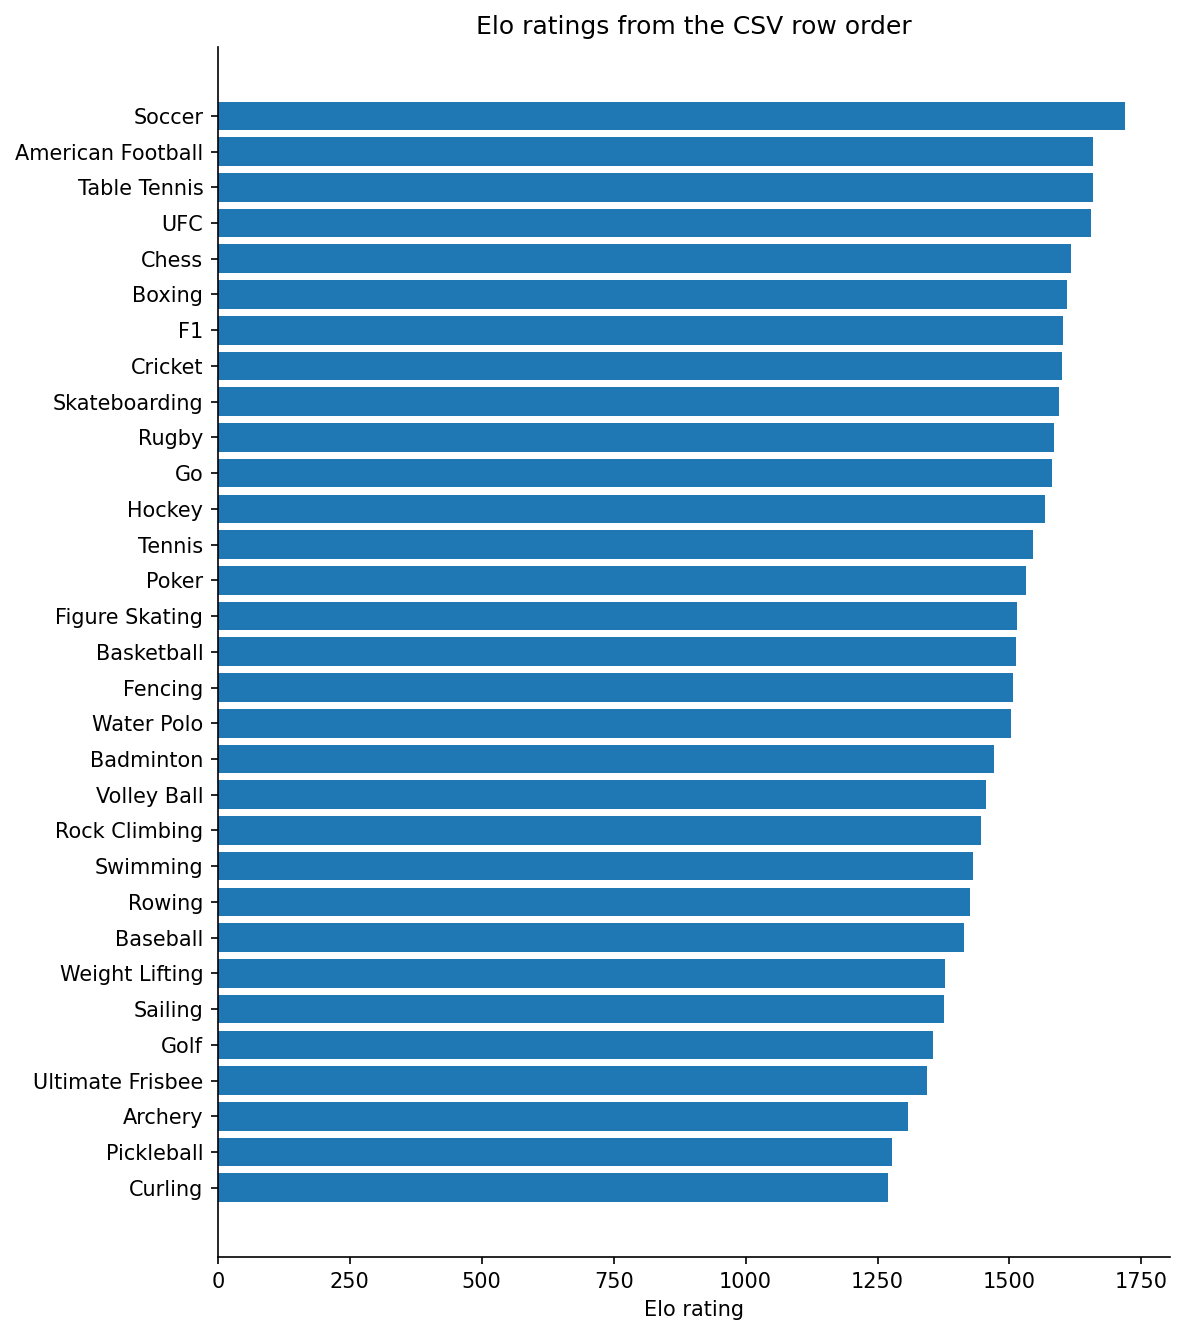

In [46]:
plot_score_bars(
    elo_df["elo"].to_numpy(),
    elo_df["sport"].to_numpy(),
    "Elo ratings from the CSV row order",
    "Elo rating",
)

Compare those Elo ratings to Bradley-Terry.

In [47]:
elo_compare = pd.DataFrame({
    "sport": sports,
    "bt_rank": pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="min").astype(int),
    "elo_rank": pd.Series(elo_full).rank(ascending=False, method="min").astype(int),
})

elo_compare["abs_rank_diff"] = (elo_compare["bt_rank"] - elo_compare["elo_rank"]).abs()

display(elo_compare.sort_values("abs_rank_diff", ascending=False).head(12))

rho_bt_elo = spearmanr(
    pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="average"),
    pd.Series(elo_full).rank(ascending=False, method="average"),
).statistic

print(f"Spearman correlation between Bradley-Terry and Elo ranks: {rho_bt_elo:0.3f}")

,sport,bt_rank,elo_rank,abs_rank_diff
21,Skateboarding,22,9,13
3,Baseball,13,24,11
4,Basketball,5,16,11
24,Table Tennis,12,3,9
25,Tennis,6,13,7
12,Go,18,11,7
17,Rock Climbing,14,21,7
11,Figure Skating,22,15,7
6,Chess,11,5,6
16,Poker,20,14,6


Spearman correlation between Bradley-Terry and Elo ranks: 0.809


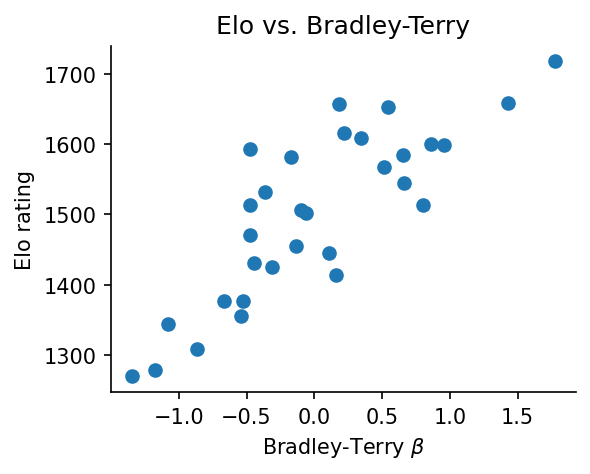

In [48]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(beta_bt, elo_full)
ax.set_title("Elo vs. Bradley-Terry")
ax.set_xlabel(r"Bradley-Terry $\beta$")
ax.set_ylabel("Elo rating")

plt.show()

The relationship is still strong, but now we finally see a method that can drift away from the balanced-data consensus.

That drift is not mysterious. Elo depends on path.

## 3.5 Order dependence

A global likelihood fit does not care whether we feed the rows in one order or another. Elo does.

So let us shuffle the rows, rerun Elo many times, and measure how much the final ratings move.

In [49]:
rng_local = np.random.default_rng(SEED)

elo_samples = []
elo_rhos = []

for _ in range(60):
    order = rng_local.permutation(len(ballots))
    ratings = elo_ratings(
        ballots["i"].to_numpy(),
        ballots["j"].to_numpy(),
        ballots["choice"].to_numpy(),
        n,
        K=16,
        order=order,
    )

    elo_samples.append(ratings)
    elo_rhos.append(
        spearmanr(
            pd.Series(ratings).rank(ascending=False, method="average"),
            pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="average"),
        ).statistic
    )

elo_samples = np.vstack(elo_samples)

elo_order_df = pd.DataFrame({
    "sport": sports,
    "rating_sd": elo_samples.std(axis=0),
}).sort_values("rating_sd", ascending=False)

display(elo_order_df.head(10))
print(f"Mean Spearman vs. Bradley-Terry across shuffles: {np.mean(elo_rhos):0.3f}")

,sport,rating_sd
6,Chess,37.638
12,Go,36.045
22,Soccer,36.039
29,Water Polo,35.093
13,Golf,34.852
24,Table Tennis,34.653
11,Figure Skating,34.387
5,Boxing,34.164
26,UFC,34.032
27,Ultimate Frisbee,33.546


Mean Spearman vs. Bradley-Terry across shuffles: 0.959


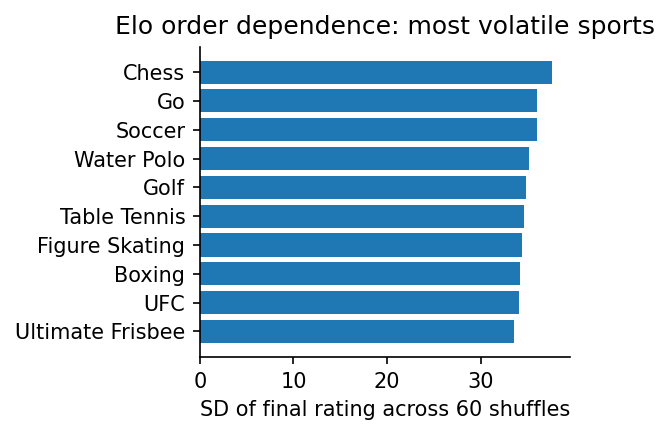

In [50]:
top_sd = elo_order_df.head(10).sort_values("rating_sd")

fig, ax = plt.subplots(figsize=(4, 3))
ax.barh(top_sd["sport"], top_sd["rating_sd"])
ax.set_title("Elo order dependence: most volatile sports")
ax.set_xlabel("SD of final rating across 60 shuffles")
plt.tight_layout()

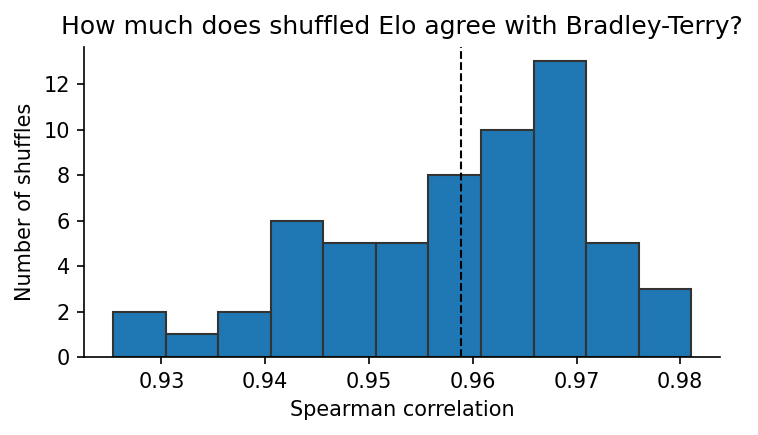

In [51]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(elo_rhos, bins=11, ec='.2')
ax.axvline(np.mean(elo_rhos), linestyle="--", color="black", linewidth=1)
ax.set_title("How much does shuffled Elo agree with Bradley-Terry?")
ax.set_xlabel("Spearman correlation")
ax.set_ylabel("Number of shuffles")
plt.tight_layout()

A shuffled Elo run usually lands fairly close to Bradley-Terry on this dataset, but not exactly. The disagreement is real, and it comes entirely from processing order.

## 3.6 The $K$-factor controls volatility

Bigger $K$ means faster adaptation and more path dependence. Smaller $K$ means slower adaptation and more stability.

In [52]:
k_rows = []

for K in [4, 8, 16, 24, 32]:
    rng_local = np.random.default_rng(SEED + K)
    samples = []
    rhos = []

    for _ in range(30):
        order = rng_local.permutation(len(ballots))
        ratings = elo_ratings(
            ballots["i"].to_numpy(),
            ballots["j"].to_numpy(),
            ballots["choice"].to_numpy(),
            n,
            K=K,
            order=order,
        )

        samples.append(ratings)
        rhos.append(
            spearmanr(
                pd.Series(ratings).rank(ascending=False, method="average"),
                pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="average"),
            ).statistic
        )

    samples = np.vstack(samples)

    k_rows.append({
        "K": K,
        "mean_rating_sd": samples.std(axis=0).mean(),
        "mean_spearman_vs_bt": np.mean(rhos),
    })

k_df = pd.DataFrame(k_rows)
display(k_df)

,K,mean_rating_sd,mean_spearman_vs_bt
0,4,10.014,0.992
1,8,19.770,0.980
2,16,30.712,0.961
3,24,39.939,0.945
4,32,48.124,0.925


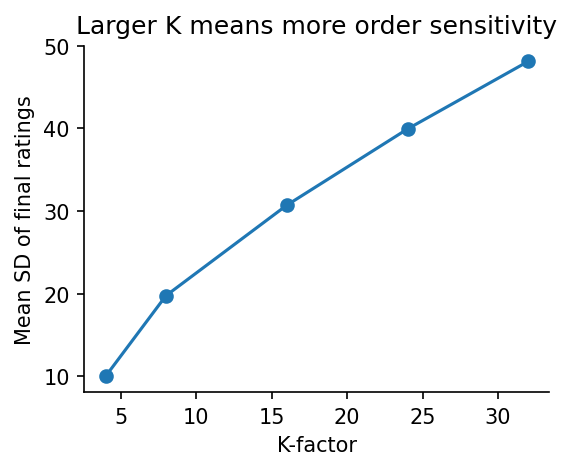

In [53]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(k_df["K"], k_df["mean_rating_sd"], marker="o")
ax.set_title("Larger K means more order sensitivity")
ax.set_xlabel("K-factor")
ax.set_ylabel("Mean SD of final ratings")

plt.show()

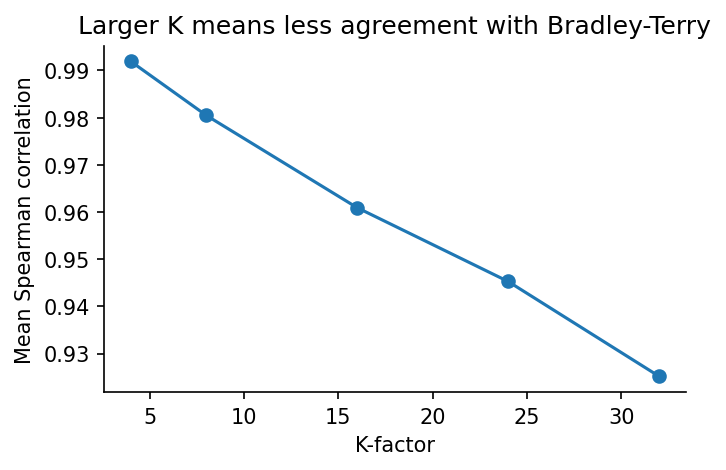

In [54]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(k_df["K"], k_df["mean_spearman_vs_bt"], marker="o")
ax.set_title("Larger K means less agreement with Bradley-Terry")
ax.set_xlabel("K-factor")
ax.set_ylabel("Mean Spearman correlation")

plt.show()

For a static dataset like this one, Elo is best read as an approximation tool, not as a gold standard.

If the comparisons really arrived over time and the underlying preferences drifted, the online update would be a feature. Here it is mostly a sensitivity analysis.

## Your turn!

Try three Elo runs with the same $K$ but different random row orders.

- Which sports move the most?
- Are those sports near the middle of the ranking or near the extremes?
- Why would you expect that pattern?

# Part IV: SpringRank, a physical model

## 4.1 A different starting point

Bradley-Terry and Elo both attach one score to each sport and then turn score differences into probabilities.

SpringRank starts somewhere else. It asks for a ranking that best fits the **whole directed comparison graph**.

![](images/sr.png)

Imagine placing each sport on a vertical line. Every directed comparison $i \to j$ acts like a spring that wants sport $i$ to sit one unit above sport $j$.

If $A_{ij}$ counts how many times $i$ beat $j$, the total spring energy is

$$
H(s) = \frac{1}{2}\sum_{ij} A_{ij}(s_i - s_j - 1)^2.
$$

A good ranking is a vector $s$ that makes this energy small.

If all the comparisons agree with one clean hierarchy, the springs are easy to satisfy.

If the data contain cycles or noisy reversals, some springs have to stay stretched. That is what the energy measures.

## 4.2 Deriving the linear system

Take the derivative of $H(s)$ with respect to one coordinate $s_k$ and set it to zero.

After collecting terms, the first-order condition becomes

$$
(d_k^{\text{out}} + d_k^{\text{in}}) s_k
- \sum_j (A_{kj} + A_{jk}) s_j
=
d_k^{\text{out}} - d_k^{\text{in}},
$$

where

$$
d_k^{\text{out}} = \sum_j A_{kj},
\qquad
d_k^{\text{in}} = \sum_j A_{jk}.
$$

Stacking those equations gives a Laplacian-style system
$$
L s = b.
$$

So SpringRank has a big practical difference from Bradley-Terry:

- Bradley-Terry needs iterative optimization,
- SpringRank reduces to solving a linear system.

## 4.3 Implement SpringRank from scratch

In [55]:
def springrank_scores(A, alpha=1e-8):
    """Compute SpringRank scores by solving a linear system.
    
    The energy to minimize is H(s) = 0.5 * sum_ij A_ij * (s_i - s_j - 1)^2.
    Setting dH/ds = 0 gives a linear system: L @ s = b
    where L is a Laplacian-like matrix and b encodes net directionality.
    """
    A = csr_matrix(np.asarray(A, dtype=float))

    # Out-degree and in-degree (how often each sport wins/loses)
    d_out = np.asarray(A.sum(axis=1)).ravel()
    d_in = np.asarray(A.sum(axis=0)).ravel()

    # Build the Laplacian-like matrix: L = D_out + D_in - (A + A^T) + alpha*I
    # The alpha*I regularization ensures the system is solvable
    D = diags(d_out + d_in)
    L = D - (A + A.T) + alpha * identity(A.shape[0])

    # Right-hand side: net directionality (out-degree minus in-degree)
    b = d_out - d_in

    # Solve the sparse linear system
    s, info = cg(L, b, atol=1e-12)
    if info != 0:
        s = spsolve(L.tocsc(), b)

    return s - s.mean()  # center scores at zero

In [56]:
def springrank_energy(A, s):
    A = np.asarray(A, dtype=float)
    i, j = np.nonzero(A)
    diff = s[i] - s[j] - 1.0
    return 0.5 * np.sum(A[i, j] * diff * diff)

In [57]:
toy_A = np.array([
    [0, 3, 2, 0],
    [0, 0, 3, 1],
    [1, 0, 0, 3],
    [0, 1, 0, 0],
])

toy_labels = ["A", "B", "C", "D"]
toy_spring = springrank_scores(toy_A)

display(
    pd.DataFrame({"sport": toy_labels, "spring": toy_spring})
    .sort_values("spring", ascending=False)
)

,sport,spring
0,A,0.654
1,B,0.057
2,C,-0.083
3,D,-0.627


That toy example mixes a rough hierarchy with a few contradictory edges. SpringRank resolves the tension by finding the score vector that minimizes total strain.

## 4.4 SpringRank on the sports-complexity data

In [58]:
spring_full = springrank_scores(A)

spring_df = pd.DataFrame({"sport": sports, "spring": spring_full})
spring_df = spring_df.sort_values(["spring", "sport"], ascending=[False, True]).reset_index(drop=True)

display(spring_df.head(12))

,sport,spring
0,Soccer,0.665
1,American Football,0.569
2,Cricket,0.407
3,F1,0.371
4,Basketball,0.347
5,Tennis,0.290
6,Rugby,0.286
7,UFC,0.242
8,Hockey,0.230
9,Boxing,0.157


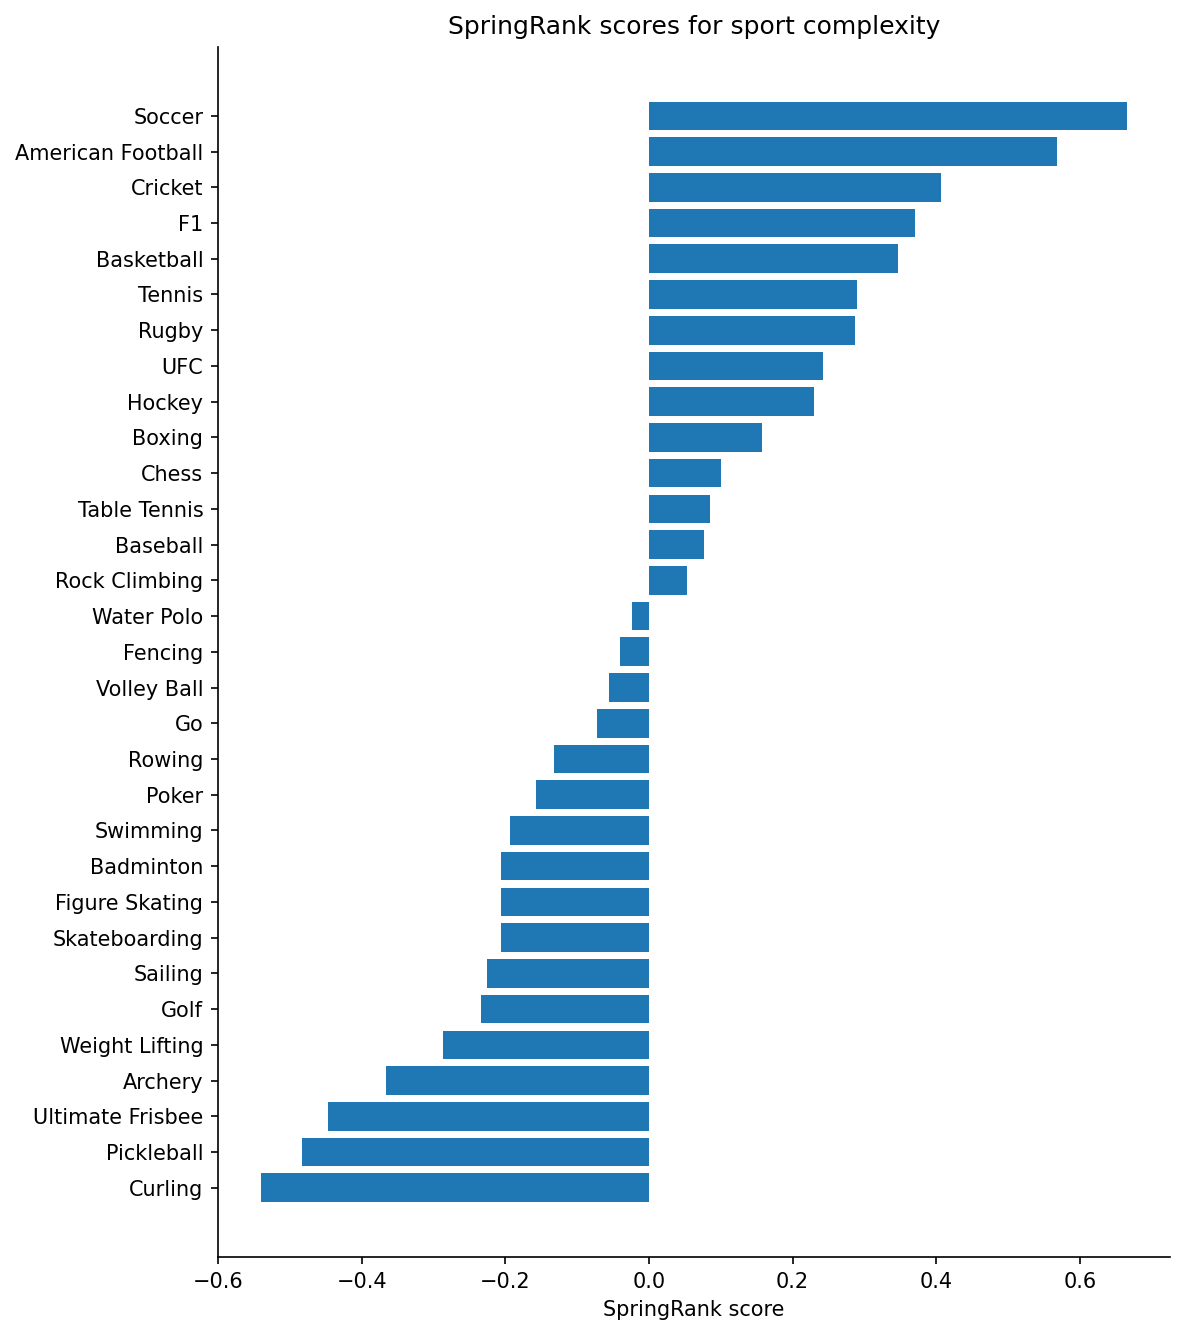

In [59]:
plot_score_bars(
    spring_df["spring"].to_numpy(),
    spring_df["sport"].to_numpy(),
    "SpringRank scores for sport complexity",
    "SpringRank score",
)

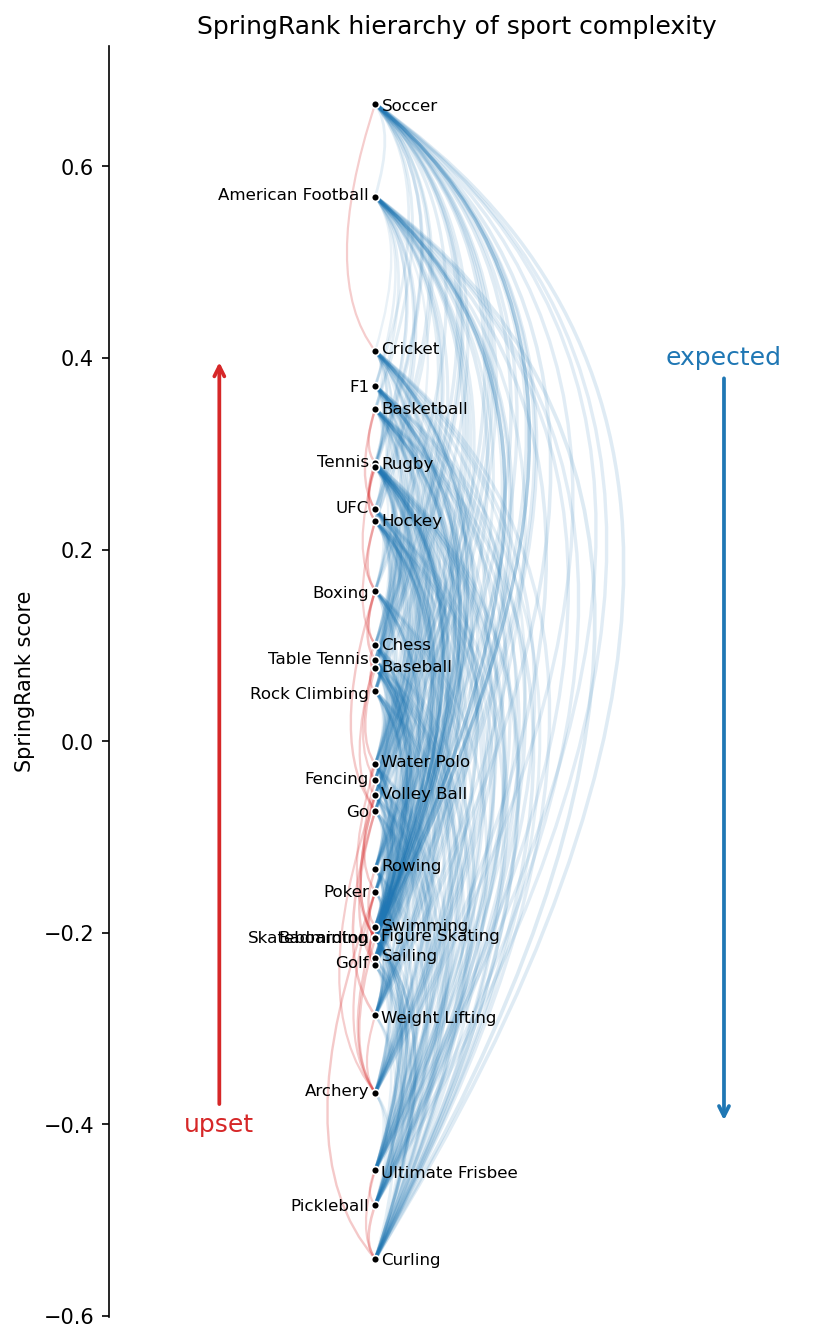

In [60]:
# SpringRank hierarchy visualization
# Sports placed vertically by their SpringRank score.
# Each pair gets one arc in the majority direction:
#   BLUE (right) = expected (higher-ranked sport chosen)
#   RED (left)   = upset (lower-ranked sport chosen)
# Wider arcs = larger score gap between the two sports.

from matplotlib.path import Path
from matplotlib.patches import PathPatch

fig, ax = plt.subplots(figsize=(6, 11))
x0 = 0.5

for i_idx in range(n):
    for j_idx in range(i_idx + 1, n):
        w_ij = A[i_idx, j_idx]
        w_ji = A[j_idx, i_idx]
        if w_ij + w_ji == 0:
            continue
        if w_ij >= w_ji:
            winner, loser, weight = i_idx, j_idx, w_ij
        else:
            winner, loser, weight = j_idx, i_idx, w_ji

        sw, sl = spring_full[winner], spring_full[loser]
        consistent = sw > sl

        side = 1.0 if consistent else -1.0
        span = abs(sw - sl)
        bulge = 0.02 + 0.9 * span**1.5  # wider arcs for distant pairs

        xc = x0 + side * bulge
        yc = 0.7 * sw + 0.3 * sl

        path = Path([(x0, sw), (xc, yc), (x0, sl)],
                     [Path.MOVETO, Path.CURVE3, Path.CURVE3])

        majority_frac = weight / (w_ij + w_ji)
        lw = 0.3 + 1.5 * majority_frac

        if consistent:
            color = "#1f77b4"
            alpha_val = 0.03 + 0.12 * majority_frac
        else:
            color = "#d62728"
            alpha_val = 0.08 + 0.30 * majority_frac

        patch = PathPatch(path, facecolor="none", edgecolor=color,
                        lw=lw, alpha=alpha_val)
        ax.add_patch(patch)

# Small black dots with white outline, alternating labels
sr_order = np.argsort(spring_full)[::-1]
scores_ordered = [spring_full[sr_order[r]] for r in range(n)]
ax.scatter([x0] * n, scores_ordered, s=14, color="black",
           edgecolors="white", linewidths=0.8, zorder=5)

for r in range(n):
    if r % 2 == 0:
        ax.text(x0 + 0.015, spring_full[sr_order[r]]+np.random.normal(0,0.002), sports[sr_order[r]],
                fontsize=8, va="center", ha="left", zorder=6)
    else:
        ax.text(x0 - 0.015, spring_full[sr_order[r]]+np.random.normal(0,0.002), sports[sr_order[r]],
                fontsize=8, va="center", ha="right", zorder=6)


# Legend arrows
ax.annotate("upset", xy=(0.12, 0.4), xytext=(0.12, -0.4),
            arrowprops=dict(arrowstyle="->", lw=1.8, color="#d62728"),
            color="#d62728", fontsize=12, ha="center", va="center")
ax.annotate("expected", xy=(1.35, -0.4), xytext=(1.35, 0.4),
            arrowprops=dict(arrowstyle="->", lw=1.8, color="#1f77b4"),
            color="#1f77b4", fontsize=12, ha="center", va="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.set_xlim(-0.15, 1.55)
ax.set_ylabel("SpringRank score")
ax.set_title("SpringRank hierarchy of sport complexity")
ax.set_xticks([])

# plt.savefig('images/springrank_complexity.png',dpi=425,bbox_inches='tight')
plt.show()

Blue arcs (curving right) are comparisons that go with the ranking — the higher-ranked sport was chosen as more complex. Red arcs (curving left) are upsets. Wider arcs connect sports that are further apart in the ranking. The vertical position is the actual SpringRank score, so the gaps between sports reflect how confident the model is about the ordering.

In [61]:
spring_compare = pd.DataFrame({
    "sport": sports,
    "win_rank": pd.Series(win_counts).rank(ascending=False, method="min").astype(int),
    "bt_rank": pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="min").astype(int),
    "spring_rank": pd.Series(np.round(spring_full, 10)).rank(ascending=False, method="min").astype(int),
})

spring_compare["max_gap"] = (
    spring_compare[["win_rank", "bt_rank", "spring_rank"]].max(axis=1)
    - spring_compare[["win_rank", "bt_rank", "spring_rank"]].min(axis=1)
)

display(spring_compare.sort_values("max_gap", ascending=False).head(12))

,sport,win_rank,bt_rank,spring_rank,max_gap
0,American Football,2,2,2,0
16,Poker,20,20,20,0
29,Water Polo,15,15,15,0
28,Volley Ball,17,17,17,0
27,Ultimate Frisbee,29,29,29,0
26,UFC,8,8,8,0
25,Tennis,6,6,6,0
24,Table Tennis,12,12,12,0
23,Swimming,21,21,21,0
22,Soccer,1,1,1,0


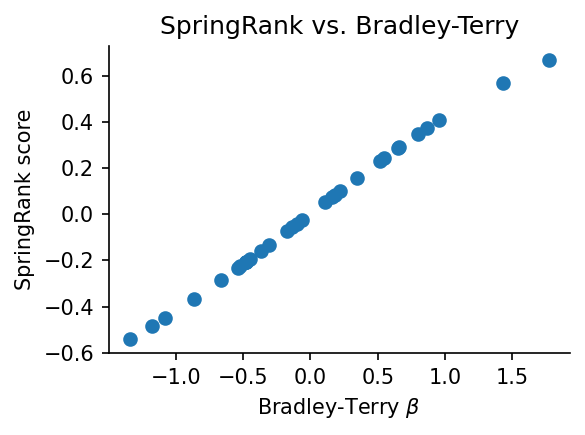

In [62]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(beta_bt, spring_full)
ax.set_title("SpringRank vs. Bradley-Terry")
ax.set_xlabel(r"Bradley-Terry $\beta$")
ax.set_ylabel("SpringRank score")
plt.tight_layout()

Again, the main surprise is how *little* the methods disagree.

SpringRank, Bradley-Terry, and raw win count are all seeing the same broad structure. On a nearly balanced round robin, that can happen.

## 4.5 Is the hierarchy stronger than random noise?

A low SpringRank energy means the comparison directions line up with a coherent hierarchy.

To test whether that is meaningful, we can keep the number of comparisons for each pair fixed and randomize only the **directions**. That gives a null model with the same undirected schedule but no real hierarchy.

In [63]:
def randomize_directions_binomial(A, seed=0):
    rng = np.random.default_rng(seed)
    A = np.asarray(A, dtype=int)
    n = A.shape[0]

    A_rand = np.zeros_like(A, dtype=int)

    for i in range(n):
        for j in range(i + 1, n):
            total = int(A[i, j] + A[j, i])
            if total == 0:
                continue

            x = rng.binomial(total, 0.5)
            A_rand[i, j] = x
            A_rand[j, i] = total - x

    return A_rand

In [64]:
observed_energy = springrank_energy(A, spring_full)

null_energies = []
for seed in range(100):
    A_null = randomize_directions_binomial(A, seed=SEED + seed)
    s_null = springrank_scores(A_null)
    null_energies.append(springrank_energy(A_null, s_null))

null_energies = np.array(null_energies)

print(f"Observed SpringRank energy: {observed_energy:0.3f}")
print(f"Null mean energy: {null_energies.mean():0.3f}")
print(f"Null SD: {null_energies.std(ddof=1):0.3f}")
print(f"Fraction of null energies <= observed: {np.mean(null_energies <= observed_energy):0.3f}")

Observed SpringRank energy: 3029.556
Null mean energy: 3705.336
Null SD: 3.961
Fraction of null energies <= observed: 0.000


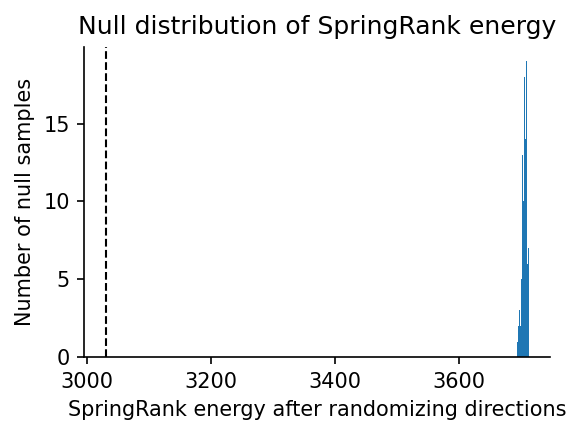

In [65]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(null_energies, bins=12)
ax.axvline(observed_energy, linestyle="--", color="black", linewidth=1)
ax.set_title("Null distribution of SpringRank energy")
ax.set_xlabel("SpringRank energy after randomizing directions")
ax.set_ylabel("Number of null samples")
plt.tight_layout()

The observed energy sits far below the null distribution.

That is exactly what we would hope to see if the ballots contain real hierarchical structure rather than just random direction assignments.

## Your turn!

Change the null model.

For example, instead of flipping each pair with probability $0.5$, preserve each sport's total win count but shuffle *who* those wins are against. Does the hierarchy still look unusually strong?

# Part V: Comparing the methods

## 5.1 Side-by-side ranking table

Put the four main methods next to each other:

- win count,
- Bradley-Terry,
- Elo,
- SpringRank.

In [66]:
rank_cols = ["Win count", "Bradley-Terry", "Elo (csv order)", "SpringRank"]

final_ranks = pd.DataFrame({
    "sport": sports,
    "Win count": pd.Series(win_counts).rank(ascending=False, method="min").astype(int),
    "Bradley-Terry": pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="min").astype(int),
    "Elo (csv order)": pd.Series(elo_full).rank(ascending=False, method="min").astype(int),
    "SpringRank": pd.Series(np.round(spring_full, 10)).rank(ascending=False, method="min").astype(int),
})

final_ranks["spread"] = (
    final_ranks[rank_cols].max(axis=1) - final_ranks[rank_cols].min(axis=1)
)

final_ranks = final_ranks.sort_values(["Bradley-Terry", "sport"]).reset_index(drop=True)

display(final_ranks)

,sport,Win count,Bradley-Terry,Elo (csv order),SpringRank,spread
0,Soccer,1,1,1,1,0
1,American Football,2,2,2,2,0
2,Cricket,3,3,8,3,5
3,F1,4,4,7,4,3
4,Basketball,5,5,16,5,11
5,Tennis,6,6,13,6,7
6,Rugby,7,7,10,7,3
7,UFC,8,8,4,8,4
8,Hockey,9,9,12,9,3
9,Boxing,10,10,6,10,4


A small spread means the methods basically agree on that sport.

A large spread means at least one method is doing something noticeably different.

In [67]:
spread_df = final_ranks.sort_values(["spread", "Bradley-Terry"], ascending=[False, True])
display(spread_df.head(12))

,sport,Win count,Bradley-Terry,Elo (csv order),SpringRank,spread
23,Skateboarding,22,22,9,22,13
4,Basketball,5,5,16,5,11
12,Baseball,13,13,24,13,11
11,Table Tennis,12,12,3,12,9
5,Tennis,6,6,13,6,7
13,Rock Climbing,14,14,21,14,7
17,Go,18,18,11,18,7
22,Figure Skating,22,22,15,22,7
10,Chess,11,11,5,11,6
19,Poker,20,20,14,20,6


On this dataset, most of the spread is coming from Elo. The other three methods mostly move together.

## 5.2 Rank correlations

In [68]:
rank_vectors = final_ranks.set_index("sport")[rank_cols]

spearman_df = pd.DataFrame(index=rank_cols, columns=rank_cols, dtype=float)
kendall_df = pd.DataFrame(index=rank_cols, columns=rank_cols, dtype=float)

for c1 in rank_cols:
    for c2 in rank_cols:
        spearman_df.loc[c1, c2] = spearmanr(rank_vectors[c1], rank_vectors[c2]).statistic
        kendall_df.loc[c1, c2] = kendalltau(rank_vectors[c1], rank_vectors[c2]).statistic

display(spearman_df.round(3))
display(kendall_df.round(3))

,Win count,Bradley-Terry,Elo (csv order),SpringRank
Win count,1.000,1.000,0.809,1.000
Bradley-Terry,1.000,1.000,0.809,1.000
Elo (csv order),0.809,0.809,1.000,0.809
SpringRank,1.000,1.000,0.809,1.000


,Win count,Bradley-Terry,Elo (csv order),SpringRank
Win count,1.000,1.000,0.617,1.000
Bradley-Terry,1.000,1.000,0.617,1.000
Elo (csv order),0.617,0.617,1.000,0.617
SpringRank,1.000,1.000,0.617,1.000


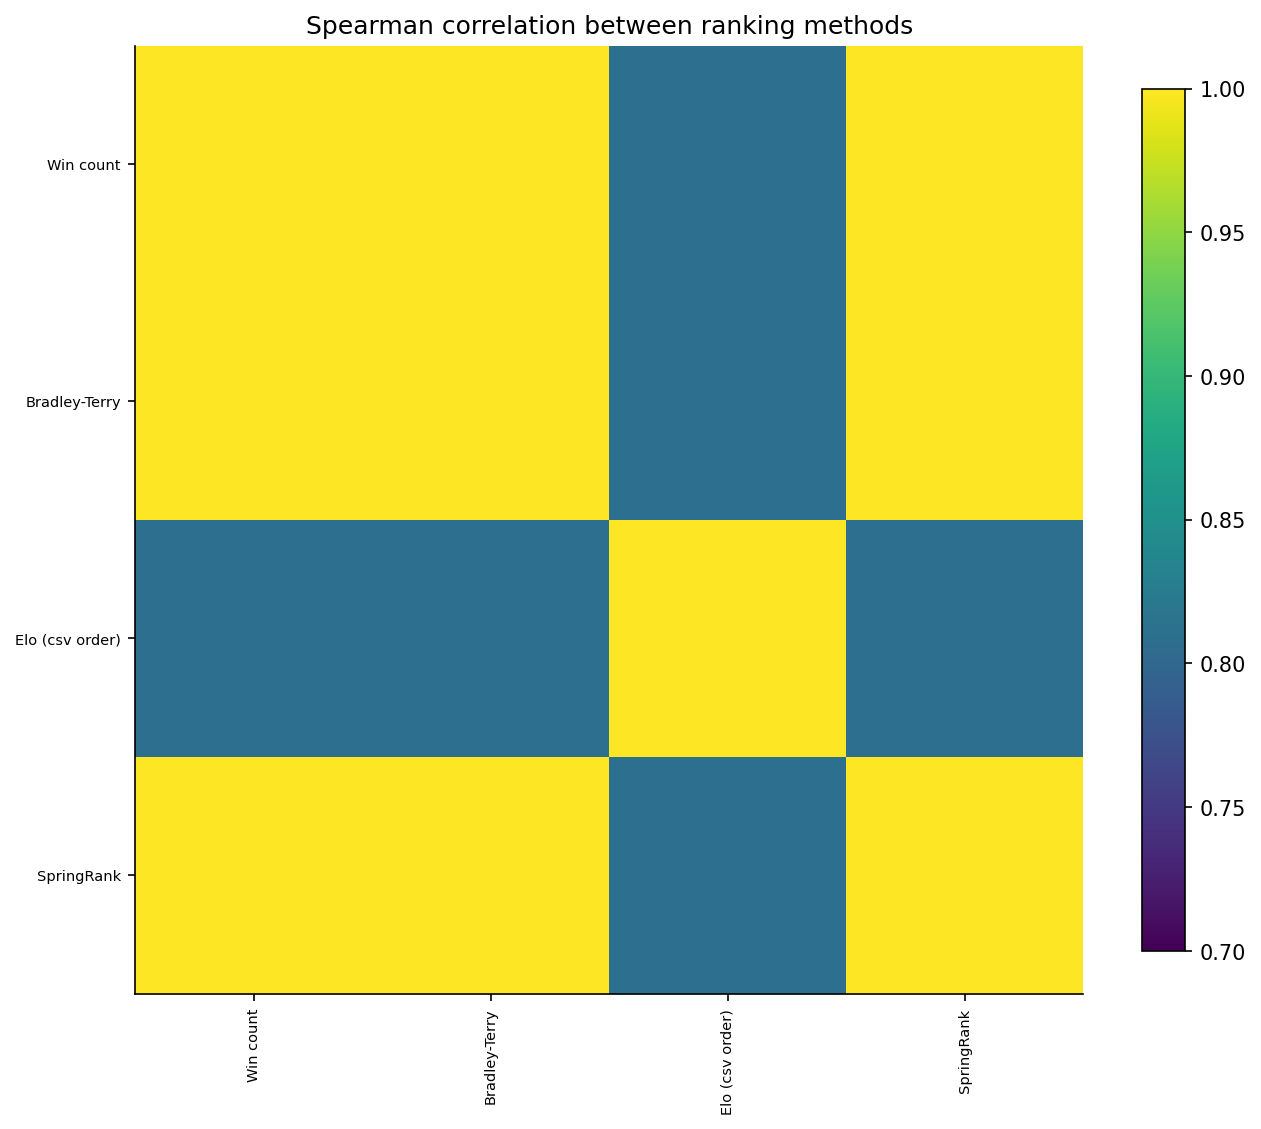

In [69]:
plot_heatmap(
    spearman_df.to_numpy(),
    spearman_df.index.tolist(),
    "Spearman correlation between ranking methods",
    vmin=0.7,
    vmax=1.0,
    cmap="viridis",
)

The rank-correlation table is the cleanest summary of the whole chapter.

For these ballots:

- win count and Bradley-Terry are nearly identical,
- SpringRank sits on top of that same structure,
- Elo is still related, but it is the outlier because of path dependence.

## 5.3 Predictive evaluation on held-out comparisons

There is a difference between producing a ranking and producing good **probabilities**.

To test that, we hold out some comparisons, fit each method on the rest, and ask how well the fitted scores predict the held-out winners.

Bradley-Terry and Elo already come with probability formulas.

Win count and SpringRank are just scores, so we will calibrate them with a one-parameter logistic link on the training data. That keeps the comparison fair: every method gets turned into out-of-sample win probabilities.

In [70]:
def fit_score_scale(scores, winner_idx, loser_idx):
    diff = scores[winner_idx] - scores[loser_idx]

    def objective(log_gamma):
        gamma = np.exp(log_gamma)
        return np.sum(softplus(-gamma * diff))

    result = minimize_scalar(objective, bounds=(-8, 8), method="bounded")
    return np.exp(result.x)


def evaluate_probabilities(probs):
    probs = np.clip(np.asarray(probs), 1e-8, 1 - 1e-8)
    logloss = -np.mean(np.log(probs))
    accuracy = np.mean(probs >= 0.5)
    return logloss, accuracy

In [71]:
def one_split_scores(train_rows, test_rows, n, K=16):
    A_train = count_matrix_from_rows(train_rows, n)
    win_train = A_train.sum(axis=1)

    beta_train, _ = fit_bradley_terry(
        train_rows["i"].to_numpy(),
        train_rows["j"].to_numpy(),
        train_rows["choice"].to_numpy(),
        n,
    )
    spring_train = springrank_scores(A_train)

    elo_train = elo_ratings(
        train_rows["i"].to_numpy(),
        train_rows["j"].to_numpy(),
        train_rows["choice"].to_numpy(),
        n,
        K=K,
    )

    winner_test = test_rows["winner_idx"].to_numpy()
    loser_test = test_rows["loser_idx"].to_numpy()

    gamma_win = fit_score_scale(
        win_train,
        train_rows["winner_idx"].to_numpy(),
        train_rows["loser_idx"].to_numpy(),
    )
    gamma_spring = fit_score_scale(
        spring_train,
        train_rows["winner_idx"].to_numpy(),
        train_rows["loser_idx"].to_numpy(),
    )

    probs = {
        "Win count": sigmoid(gamma_win * (win_train[winner_test] - win_train[loser_test])),
        "Bradley-Terry": sigmoid(beta_train[winner_test] - beta_train[loser_test]),
        "SpringRank": sigmoid(gamma_spring * (spring_train[winner_test] - spring_train[loser_test])),
        "Elo": 1 / (1 + 10 ** ((elo_train[loser_test] - elo_train[winner_test]) / 400)),
    }

    rows = []
    for name, p in probs.items():
        logloss, accuracy = evaluate_probabilities(p)
        rows.append({"method": name, "logloss": logloss, "accuracy": accuracy})

    return pd.DataFrame(rows).sort_values("logloss")

In [72]:
rng_local = np.random.default_rng(SEED)
all_idx = rng_local.permutation(len(ballots))
cut = int(0.8 * len(ballots))

train_rows = ballots.iloc[np.sort(all_idx[:cut])].copy()
test_rows = ballots.iloc[np.sort(all_idx[cut:])].copy()

one_split_df = one_split_scores(train_rows, test_rows, n)
display(one_split_df)

,method,logloss,accuracy
1,Bradley-Terry,0.592,0.685
2,SpringRank,0.593,0.685
0,Win count,0.593,0.689
3,Elo,0.620,0.655


In [73]:
eval_rows = []

for split_seed in range(SEED, SEED + 10):
    rng_local = np.random.default_rng(split_seed)
    all_idx = rng_local.permutation(len(ballots))
    cut = int(0.8 * len(ballots))

    train_rows = ballots.iloc[np.sort(all_idx[:cut])].copy()
    test_rows = ballots.iloc[np.sort(all_idx[cut:])].copy()

    split_df = one_split_scores(train_rows, test_rows, n)
    split_df["split_seed"] = split_seed
    eval_rows.append(split_df)

eval_df = pd.concat(eval_rows, ignore_index=True)

eval_summary = (
    eval_df
    .groupby("method")
    .agg(
        mean_logloss=("logloss", "mean"),
        sd_logloss=("logloss", "std"),
        mean_accuracy=("accuracy", "mean"),
        sd_accuracy=("accuracy", "std"),
    )
    .sort_values("mean_logloss")
)

display(eval_summary)

,mean_logloss,sd_logloss,mean_accuracy,sd_accuracy
method,,,,
Bradley-Terry,0.599,0.005,0.681,0.007
SpringRank,0.600,0.005,0.681,0.007
Win count,0.600,0.006,0.684,0.007
Elo,0.631,0.011,0.650,0.012


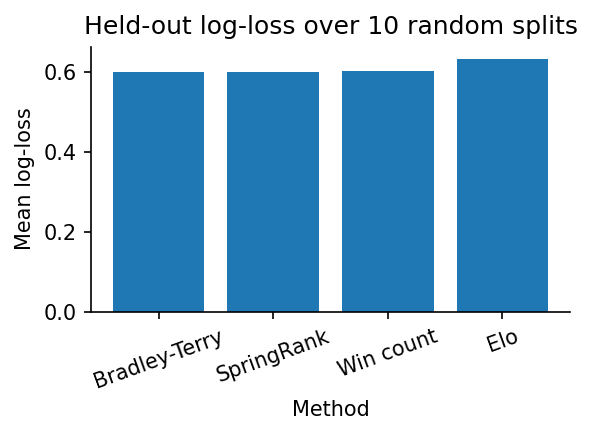

In [74]:
plot_data = eval_summary.reset_index().sort_values("mean_logloss")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(plot_data["method"], plot_data["mean_logloss"])
ax.set_title("Held-out log-loss over 10 random splits")
ax.set_xlabel("Method")
ax.set_ylabel("Mean log-loss")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

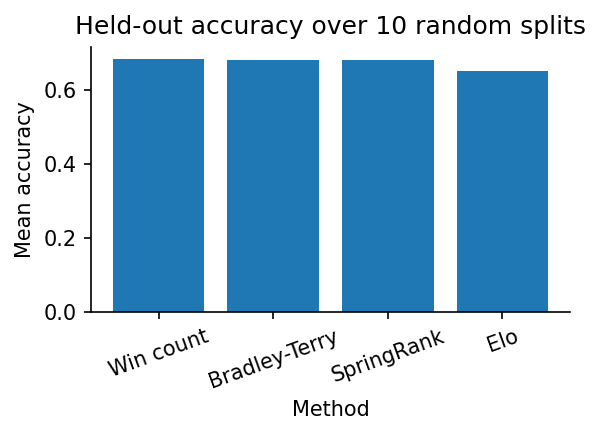

In [75]:
plot_data = eval_summary.reset_index().sort_values("mean_accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(plot_data["method"], plot_data["mean_accuracy"])
ax.set_title("Held-out accuracy over 10 random splits")
ax.set_xlabel("Method")
ax.set_ylabel("Mean accuracy")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

The predictive comparison matches the ranking comparison.

Bradley-Terry, SpringRank, and calibrated win count are all extremely close on this dataset. Elo trails because the row order is arbitrary, so the online updates are solving the wrong problem.

## 5.4 What did we learn about the sports?

At the very top and bottom, the methods mostly agree. The interesting action is in the middle, where voters disagree more and where Elo's order sensitivity shows up most clearly.

In [76]:
display(final_ranks.head(10))
display(final_ranks.tail(10))

,sport,Win count,Bradley-Terry,Elo (csv order),SpringRank,spread
0,Soccer,1,1,1,1,0
1,American Football,2,2,2,2,0
2,Cricket,3,3,8,3,5
3,F1,4,4,7,4,3
4,Basketball,5,5,16,5,11
5,Tennis,6,6,13,6,7
6,Rugby,7,7,10,7,3
7,UFC,8,8,4,8,4
8,Hockey,9,9,12,9,3
9,Boxing,10,10,6,10,4


,sport,Win count,Bradley-Terry,Elo (csv order),SpringRank,spread
21,Badminton,22,22,19,22,3
22,Figure Skating,22,22,15,22,7
23,Skateboarding,22,22,9,22,13
24,Sailing,25,25,26,25,1
25,Golf,26,26,27,26,1
26,Weight Lifting,27,27,25,27,2
27,Archery,28,28,29,28,1
28,Ultimate Frisbee,29,29,28,29,1
29,Pickleball,30,30,30,30,0
30,Curling,31,31,31,31,0


Different methods are only one source of disagreement. Different **voters** are another.

We can fit Bradley-Terry separately for each voter and ask which sports move around the most across voters.

In [77]:
voter_bt_rank_rows = []

for voter, rows in ballots.groupby("voter"):
    beta_v, _ = fit_bradley_terry(
        rows["i"].to_numpy(),
        rows["j"].to_numpy(),
        rows["choice"].to_numpy(),
        n,
    )

    ranks_v = pd.Series(beta_v).rank(ascending=False, method="average").to_numpy()

    for sport, rank in zip(sports, ranks_v):
        voter_bt_rank_rows.append({
            "voter": voter,
            "sport": sport,
            "bt_rank": rank,
        })

voter_bt_rank_df = pd.DataFrame(voter_bt_rank_rows)

In [78]:
voter_disagreement_df = (
    voter_bt_rank_df
    .groupby("sport")
    .agg(
        mean_rank=("bt_rank", "mean"),
        sd_rank=("bt_rank", "std"),
    )
    .sort_values("sd_rank", ascending=False)
    .reset_index()
)

display(voter_disagreement_df.head(12))

,sport,mean_rank,sd_rank
0,Poker,19.312,10.866
1,Go,17.094,10.640
2,Chess,13.812,10.294
3,Cricket,10.094,9.942
4,Weight Lifting,20.312,8.979
5,Swimming,18.625,8.665
6,UFC,12.031,8.568
7,Ultimate Frisbee,23.781,8.163
8,Figure Skating,18.531,8.129
9,Baseball,15.219,8.062


Sports with large cross-voter rank variation are the ones people do not evaluate on the same mental scale.

That is the most interesting substantive result in the notebook. "Complexity" is not one thing. For some sports, different voters are clearly using different definitions.

# Summary

Ranking from pairwise comparisons looks easy until you inspect the data! In this survey, the ballots contain local cycles, many close pairs, and noticeable disagreement across voters. Bradley-Terry, Elo, and SpringRank all respond to that mess differently. For these particular data, the big empirical lesson is that a nearly balanced round robin pushes several methods toward the same answer. Bradley-Terry, SpringRank, and even calibrated win count are almost indistinguishable. Elo is the one that moves more, and it moves because order matters.

That is a good place to end: not with "which method wins?", but with "what features of the data make methods agree or disagree?"

_____________

# Appendix A: When win count is a special case

Suppose three things are true:

1. every pair of sports is compared the same number of times,
2. the pairwise relation is perfectly transitive,
3. there are no contradictory outcomes.

Then the ranking is already encoded by win count.

Write the sports in the true order as

$$
i_1 \succ i_2 \succ \cdots \succ i_n.
$$

If each higher-ranked sport beats each lower-ranked sport exactly $m$ times, then sport $i_a$ gets

$$
w_{i_a} = m(n-a)
$$

wins.

So the win counts are strictly ordered in exactly the same way as the true ranking.

Bradley-Terry agrees with that order too.

In the noiseless transitive case, every observed comparison points in the same direction as the true order. The Bradley-Terry likelihood therefore increases as the fitted gaps $\beta_{i_a} - \beta_{i_b}$ line up with that order. Any maximum-likelihood solution must preserve the same ranking, because reversing any pair would lower the likelihood on all of their direct comparisons.

That is the clean special case.

The methods start to diverge when the data stop satisfying those assumptions:

- **unbalanced schedule:** some wins are harder to get than others,
- **cycles:** local contradictions make one strict order impossible,
- **noise:** even with a stable underlying order, finite samples create reversals.

Our survey is close to the special case, which is why win count, Bradley-Terry, and SpringRank end up almost identical.

# Appendix B: Massey and Colley methods

Massey and Colley are classic college-football rating methods built from linear systems.

They sit in the same general family as SpringRank: scores are recovered from a matrix equation involving the comparison graph.

For a comparison matrix $A$, let $N = A + A^\top$ be the undirected matchup-count matrix.

The **Massey** system solves

$$
M r = p,
$$

where $M = \operatorname{diag}(N \mathbf{1}) - N$ and $p$ is the vector of win-loss differentials.

The **Colley** system solves

$$
C r = b,
$$

where $C = \operatorname{diag}(N \mathbf{1} + 2) - N$ and $b = 1 + \frac{1}{2}(w - \ell)$.

Colley adds a built-in shrinkage term through the `+2`.

In [79]:
def massey_scores(A):
    A = np.asarray(A, dtype=float)
    N = A + A.T

    M = np.diag(N.sum(axis=1)) - N
    p = A.sum(axis=1) - A.sum(axis=0)

    M2 = M.copy()
    b = p.copy()

    M2[-1, :] = 1.0
    b[-1] = 0.0

    return np.linalg.solve(M2, b)

In [80]:
def colley_scores(A):
    A = np.asarray(A, dtype=float)
    N = A + A.T

    C = np.diag(N.sum(axis=1) + 2.0) - N
    b = 1.0 + 0.5 * (A.sum(axis=1) - A.sum(axis=0))

    return np.linalg.solve(C, b)

In [81]:
massey = massey_scores(A)
colley = colley_scores(A)

appendix_b_df = pd.DataFrame({
    "sport": sports,
    "SpringRank": spring_full,
    "Massey": massey,
    "Colley": colley,
})

display(
    appendix_b_df
    .sort_values("SpringRank", ascending=False)
    .head(12)
)

,sport,SpringRank,Massey,Colley
22,Soccer,0.665,0.665,0.831
0,American Football,0.569,0.569,0.783
7,Cricket,0.407,0.407,0.703
9,F1,0.371,0.371,0.685
4,Basketball,0.347,0.347,0.673
25,Tennis,0.290,0.290,0.645
19,Rugby,0.286,0.286,0.643
26,UFC,0.242,0.242,0.620
14,Hockey,0.230,0.230,0.614
5,Boxing,0.157,0.157,0.578


In [82]:
appendix_b_corr = pd.DataFrame(index=["SpringRank", "Massey", "Colley"], columns=["SpringRank", "Massey", "Colley"], dtype=float)

for c1 in appendix_b_corr.index:
    for c2 in appendix_b_corr.columns:
        appendix_b_corr.loc[c1, c2] = spearmanr(
            appendix_b_df[c1].rank(ascending=False, method="average"),
            appendix_b_df[c2].rank(ascending=False, method="average"),
        ).statistic

display(appendix_b_corr.round(3))

,SpringRank,Massey,Colley
SpringRank,1.000,1.000,1.000
Massey,1.000,1.000,0.999
Colley,1.000,0.999,1.000


On this dataset, Massey and SpringRank are essentially the same ranking. That is not an accident.

Both are Laplacian-based methods driven by win-loss imbalance. Colley adds shrinkage, so the scores are compressed, but the ordering still ends up very close.

# Appendix C: Rank aggregation across voters

So far we pooled all 6,973 comparisons into one dataset and fit one ranking.

A different pipeline is:

1. fit or derive one ranking per voter,
2. aggregate those 15 rankings into a group ranking.

Those are not the same operation.

Two classic aggregation ideas are:

- **Borda count:** award points by position and sum them,
- **Kemeny aggregation:** find the ranking that agrees with the voter rankings on as many pairwise orderings as possible.

The exact Kemeny problem is computationally hard, so below we use a simple local-search heuristic rather than pretending we solved the exact optimization.

In [83]:
voter_orders = []

for voter, rows in ballots.groupby("voter"):
    beta_v, _ = fit_bradley_terry(
        rows["i"].to_numpy(),
        rows["j"].to_numpy(),
        rows["choice"].to_numpy(),
        n,
    )
    order = np.argsort(-beta_v)
    voter_orders.append(order)

In [84]:
def borda_scores_from_orders(orders):
    n = len(orders[0])
    scores = np.zeros(n, float)

    for order in orders:
        for pos, item in enumerate(order):
            scores[item] += n - 1 - pos

    return scores


def preference_matrix_from_orders(orders):
    n = len(orders[0])
    P = np.zeros((n, n), dtype=int)

    for order in orders:
        pos = np.empty(n, dtype=int)
        pos[list(order)] = np.arange(n)

        for i in range(n):
            for j in range(i + 1, n):
                if pos[i] < pos[j]:
                    P[i, j] += 1
                else:
                    P[j, i] += 1

    return P

In [85]:
def kemeny_score(order, P):
    pos = np.empty(len(order), dtype=int)
    pos[list(order)] = np.arange(len(order))

    score = 0
    n = len(order)

    for i in range(n):
        for j in range(i + 1, n):
            if pos[i] < pos[j]:
                score += P[i, j]
            else:
                score += P[j, i]

    return score


def kemeny_adjacent_improve(initial_order, P, max_passes=200):
    order = np.array(initial_order, dtype=int).copy()
    current = kemeny_score(order, P)

    improved = True
    passes = 0

    while improved and passes < max_passes:
        improved = False
        passes += 1

        for i in range(len(order) - 1):
            trial = order.copy()
            trial[i], trial[i + 1] = trial[i + 1], trial[i]
            trial_score = kemeny_score(trial, P)

            if trial_score > current:
                order = trial
                current = trial_score
                improved = True

    return order, current, passes

In [86]:
borda_scores = borda_scores_from_orders(voter_orders)
P = preference_matrix_from_orders(voter_orders)
initial_order = np.argsort(-borda_scores)

kemeny_order, kemeny_val, kemeny_passes = kemeny_adjacent_improve(initial_order, P)

borda_rank = pd.Series(borda_scores).rank(ascending=False, method="min").astype(int).to_numpy()
kemeny_rank = np.empty(n, dtype=int)
kemeny_rank[kemeny_order] = np.arange(1, n + 1)

pooled_bt_rank = pd.Series(np.round(beta_bt, 10)).rank(ascending=False, method="min").astype(int).to_numpy()

agg_df = pd.DataFrame({
    "sport": sports,
    "Borda": borda_rank,
    "Kemeny heuristic": kemeny_rank,
    "Pooled BT": pooled_bt_rank,
})

agg_df["spread"] = agg_df[["Borda", "Kemeny heuristic", "Pooled BT"]].max(axis=1) - agg_df[["Borda", "Kemeny heuristic", "Pooled BT"]].min(axis=1)

display(agg_df.sort_values(["Pooled BT", "sport"]).head(15))
print("Kemeny local-search passes:", kemeny_passes)

,sport,Borda,Kemeny heuristic,Pooled BT,spread
22,Soccer,1,1,1,0
0,American Football,2,2,2,0
7,Cricket,4,3,3,1
9,F1,5,4,4,1
4,Basketball,7,5,5,2
25,Tennis,6,7,6,1
19,Rugby,3,6,7,4
26,UFC,8,8,8,0
14,Hockey,9,10,9,1
5,Boxing,10,9,10,1


Kemeny local-search passes: 3


In [87]:
display(agg_df.sort_values("spread", ascending=False).head(12))

,sport,Borda,Kemeny heuristic,Pooled BT,spread
16,Poker,22,26,20,6
19,Rugby,3,6,7,4
30,Weight Lifting,26,25,27,2
2,Badminton,24,22,22,2
4,Basketball,7,5,5,2
20,Sailing,27,27,25,2
18,Rowing,17,17,19,2
10,Fencing,17,18,16,2
11,Figure Skating,20,20,22,2
28,Volley Ball,15,15,17,2


The aggregated rankings are close to the pooled Bradley-Terry ranking, but not identical.

That gap is conceptually important. Pooling comparisons and aggregating voter-level rankings answer slightly different questions.

# References

## Foundational paired-comparison models

- Thurstone, L. L. (1927). *A law of comparative judgment*. **Psychological Review**, 34(4), 273-286.
- Zermelo, E. (1929). *Die Berechnung der Turnier-Ergebnisse als ein Maximumproblem der Wahrscheinlichkeitsrechnung*. **Mathematische Zeitschrift**, 29, 436-460.
- Bradley, R. A., & Terry, M. E. (1952). *Rank analysis of incomplete block designs: I. The method of paired comparisons*. **Biometrika**, 39(3/4), 324-345.
- Ford, L. R., Jr. (1957). *Solution of a ranking problem from binary comparisons*. **The American Mathematical Monthly**, 64(8, Part 2), 28-33.
- Luce, R. D. (1959). *Individual Choice Behavior: A Theoretical Analysis*. Wiley.
- Davidson, R. R. (1970). *On extending the Bradley-Terry model to accommodate ties in paired comparison experiments*. **Journal of the American Statistical Association**, 65(329), 317-328.

## More on paired-comparison models

- Plackett, R. L. (1975). *The analysis of permutations*. **Journal of the Royal Statistical Society, Series C**, 24(2), 193-202.
- David, H. A. (1988). *The Method of Paired Comparisons* (2nd ed.). Oxford University Press.
- Agresti, A. (1992). *Analysis of ordinal paired comparison data*. **Journal of the Royal Statistical Society, Series C**, 41(2), 287-297.
- Hunter, D. R. (2004). *MM algorithms for generalized Bradley-Terry models*. **The Annals of Statistics**, 32(1), 384-406.
- Cattelan, M. (2012). *Models for paired comparison data: A review with emphasis on dependent data*. **Statistical Science**, 27(3), 412-433.
- Shah, N. B., & Wainwright, M. J. (2018). *Simple, robust and optimal ranking from pairwise comparisons*. **Journal of Machine Learning Research**, 18, 1-38.

## Elo, dynamic ratings, and skill models

- Elo, A. E. (1978). *The Rating of Chessplayers, Past and Present*. Arco.
- Glickman, M. E. (1999). *Parameter estimation in large dynamic paired comparison experiments*. **Journal of the Royal Statistical Society, Series C**, 48(3), 377-394.
- Fahrmeir, L., & Tutz, G. (1994). *Dynamic stochastic models for time-dependent ordered paired comparison systems*. **Journal of the American Statistical Association**, 89(428), 1438-1449.
- Glickman, M. E. (2001). *Dynamic paired comparison models with stochastic variances*. **Journal of Applied Statistics**, 28(6), 673-689.
- Herbrich, R., Minka, T., & Graepel, T. (2006). *TrueSkill: A Bayesian skill rating system*. **Advances in Neural Information Processing Systems 19**, 569-576.
- Dangauthier, P., Herbrich, R., Minka, T., & Graepel, T. (2007). *TrueSkill through time: Revisiting the history of chess*. **Advances in Neural Information Processing Systems 20**, 337-344.
- Cattelan, M., Varin, C., & Firth, D. (2013). *Dynamic Bradley-Terry modelling of sports tournaments*. **Journal of the Royal Statistical Society, Series C**, 62(1), 135-150.
- Glickman, M. E., & Jones, L. V. (2025). *Models and rating systems for head-to-head competition*. **Annual Review of Statistics and Its Application**, 12, 259-282.

## Linear systems, graph methods, and sports ranking

- Massey, K. (1997). *Statistical models applied to the rating of sports teams*. Undergraduate thesis, Bluefield College.
- Colley, W. N. (2002). *Colley's bias free college football ranking method: The Colley matrix explained*. Self-published technical report.
- Langville, A. N., & Meyer, C. D. (2012). *Who's #1? The Science of Rating and Ranking*. Princeton University Press.
- Jiang, X., Lim, L.-H., Yao, Y., & Ye, Y. (2011). *Statistical ranking and combinatorial Hodge theory*. **Mathematical Programming**, 127(1), 203-244.
- Negahban, S., Oh, S., & Shah, D. (2017). *Rank Centrality: Ranking from pairwise comparisons*. **Operations Research**, 65(1), 266-287.
- De Bacco, C., Larremore, D. B., & Moore, C. (2018). *A physical model for efficient ranking in networks*. **Science Advances**, 4(7), eaar8260.
- Newman, M. E. J. (2023). *Efficient computation of rankings from pairwise comparisons*. **Journal of Machine Learning Research**, 24, 1-25.

## Rank aggregation, social choice, and modern applications

- de Borda, J.-C. (1784). *Mémoire sur les élections au scrutin*.
- Kemeny, J. G. (1959). *Mathematics without numbers*. **Daedalus**, 88(4), 577-591.
- Mallows, C. L. (1957). *Non-null ranking models. I*. **Biometrika**, 44(1/2), 114-130.
- Marden, J. I. (1995). *Analyzing and Modeling Rank Data*. Chapman & Hall.
- Hemaspaandra, E., Spakowski, H., & Vogel, J. (2005). *The complexity of Kemeny elections*. **Theoretical Computer Science**, 349(3), 382-391.
- Chiang, W.-L., Zheng, L., Sheng, Y., et al. (2024). *Chatbot Arena: An open platform for evaluating LLMs by human preference*. **Proceedings of ICML 2024**, PMLR 235, 8359-8388.
- Daynauth, N., Gujral, A., Inusah, Y. B., et al. (2025). *Ranking unraveled: Recipes for LLM rankings in head-to-head AI combat*. **Proceedings of ACL 2025**, 26078-26091.